# Heading

In [1]:
# imports
import pm4py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lxml import etree
from pathlib import Path
from tqdm import tqdm

# Paths (adjust if needed)
LOG_PATH = Path("../0_data/BPI Challenge 2017_1_all/BPI Challenge 2017.xes")
XML_PATH = Path("../0_data/BPI Challenge 2017_1_all/DATA.xml")
OUT_DIR = Path("../0_data/bpi2017_eda_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)


## Read metadata XML

In [2]:

def read_metadata(xml_path):
    tree = etree.parse(str(xml_path))
    root = tree.getroot()
    meta = {}
    # Simple extraction of top-level numeric/text fields
    for elem in root:
        tag = elem.tag
        # get direct text or nested value
        if elem.text and elem.text.strip():
            meta[tag] = elem.text.strip()
        else:
            # collect subelements
            children = {}
            for ch in elem:
                if ch.text and ch.text.strip():
                    children[ch.tag] = ch.text.strip()
            if children:
                meta[tag] = children
    return meta

meta = read_metadata(XML_PATH)
print("XML metadata keys:", list(meta.keys()))
print("number_of_traces:", meta.get("number_of_traces"))
print("number_of_events:", meta.get("number_of_events"))


XML metadata keys: ['doi', 'name', 'description', 'language', 'log_type', 'process_type', 'creation', 'source', 'number_of_traces', 'number_of_events', 'events_per_trace', 'min_events_per_trace', 'max_events_per_trace']
number_of_traces: 31509
number_of_events: 1202267


## Read XES log

In [3]:
print("Reading XES log (this may take a while)...")
log = pm4py.read_xes(str(LOG_PATH))

n_traces = len(log)
n_events = sum(len(t) for t in log)
print(f"Traces: {n_traces}, Events: {n_events}")

Reading XES log (this may take a while)...


/Users/martinschmauch/Code/TUMCode/MasterThesis/.mt/lib/python3.12/site-packages/pm4py/utils.py:986: UserWarning: In the current version, the import/export operation uses `rustxes` by default for importing/exporting files faster. Please uninstall `rustxes` to revert the behavior.
  warnings.warn("In the current version, the import/export operation uses `rustxes` by default for importing/exporting files faster. Please uninstall `rustxes` to revert the behavior.")


Traces: 1202267, Events: 244


## Convert to pandas dataframe for EDA

In [4]:
print("Converting log to DataFrame...")
df = pm4py.convert_to_dataframe(log)

Converting log to DataFrame...


In [5]:
# normalize column names if necessary
# pm4py conversion often creates 'case:concept:name', 'concept:name', 'time:timestamp', 'org:resource'
print("Columns:", df.columns.tolist())

# ensure timestamps are datetimes
if 'time:timestamp' in df.columns:
    df['time:timestamp'] = pd.to_datetime(df['time:timestamp'])

# filter only for W_ activities
print("Number of events before filtering:", len(df))
df = df[df['concept:name'].str.startswith('W_')]
print("Filtered to W_ activities, remaining events:", len(df))


Columns: ['OfferID', 'concept:name', 'time:timestamp', 'case:ApplicationType', 'case:concept:name', 'org:resource', 'FirstWithdrawalAmount', 'EventOrigin', 'lifecycle:transition', 'case:LoanGoal', 'NumberOfTerms', 'Action', 'EventID', 'Accepted', 'OfferedAmount', 'Selected', 'CreditScore', 'case:RequestedAmount', 'MonthlyCost']
Number of events before filtering: 1202267
Filtered to W_ activities, remaining events: 768823


In [10]:
l = list(df['concept:name'].values)
# get unique activities
activities = sorted(set(l))
print("Unique activities:", activities)

Unique activities: ['W_Assess potential fraud', 'W_Call after offers', 'W_Call incomplete files', 'W_Complete application', 'W_Handle leads', 'W_Personal Loan collection', 'W_Shortened completion ', 'W_Validate application']


## Analyze W_Assess potential fraud

In [6]:
# df['activity'] = df['concept:name'].str[2:]  # remove 'W_' prefix for easier analysis
# # Basic EDA
# # df.head()
# df_a = df[(df['activity'] == 'Assess potential fraud') 
#         #   & (df['lifecycle:transition'] == 'complete')
#           ]
# # df_b = df[(df['activity'] == 'Assess potential fraud') & (df['lifecycle:transition'] == 'suspend')]
# df_a.head()

In [7]:
# df_a[df_a["org:resource"] == "User_143"].sort_values("time:timestamp")[["lifecycle:transition", "case:concept:name", "time:timestamp", "Action"]].head(40)

# Analyze personal collection and shortend completion

In [8]:
df["concept:name"].value_counts()

concept:name
W_Validate application        209496
W_Call after offers           191092
W_Call incomplete files       168529
W_Complete application        148900
W_Handle leads                 47264
W_Assess potential fraud        3282
W_Shortened completion           238
W_Personal Loan collection        22
Name: count, dtype: int64

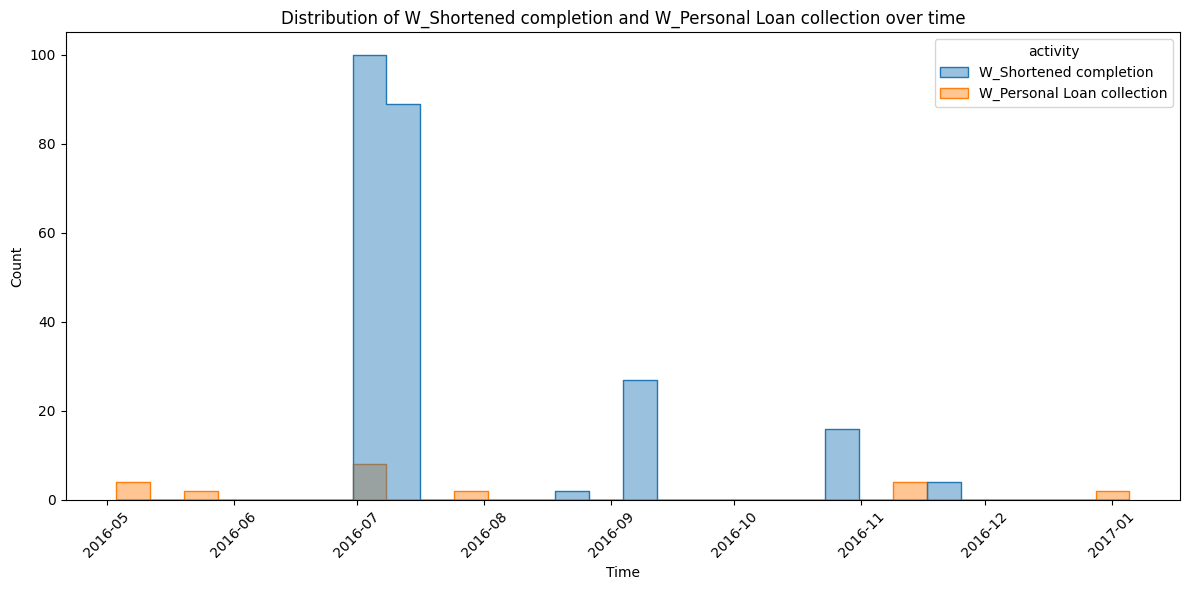

In [9]:
activities = ["W_Shortened completion ", "W_Personal Loan collection", "W_Assess potential fraud"]
df_s = df[df["concept:name"] == activities[0]][["concept:name", "time:timestamp"]]
df_p = df[df["concept:name"] == activities[1]][["concept:name", "time:timestamp"]]
df_f = df[df["concept:name"] == activities[2]][["concept:name", "time:timestamp"]]


# Visualize both activities in one graph
plot_df = pd.concat([
    df_s.assign(activity=activities[0]),
    df_p.assign(activity=activities[1]),
    # df_f.assign(activity=activities[2]),
])

plt.figure(figsize=(12, 6))
sns.histplot(
    data=plot_df,
    x='time:timestamp',
    hue='activity',
    bins=30,
    kde=False,
    element='step',
    stat='count',
    common_norm=False,
    alpha=0.45,
 )
plt.title("Distribution of W_Shortened completion and W_Personal Loan collection over time")
plt.xlabel("Time")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
# check if there are any case:concept:name that have any "W_Shortened completion " in their case if they have any "completed" lifecycle:transition
cases_with_shortened = df[df["concept:name"] == "W_Personal Loan collection"]["case:concept:name"].unique()
print(f"Cases with W_Shortened completion : {len(cases_with_shortened)}")
cases_with_completed = df[df["lifecycle:transition"] == "Completed"]["case:concept:name"].unique()
print(f"Cases with completed lifecycle: {len(cases_with_completed)}")
cases_with_both = set(cases_with_shortened) & set(cases_with_completed)
print(f"Cases with both W_Shortened completion and completed lifecycle: {len(cases_with_both)}")
# show me those case ids:
print(cases_with_both)

Cases with W_Shortened completion : 2
Cases with completed lifecycle: 0
Cases with both W_Shortened completion and completed lifecycle: 0
set()


In [11]:
# get min/max/mean duration for activities W_Shortened completion, W_Personal Loan collection, W_Assess potential fraud
activity_durations = {}
for activity in activities:
    act_df = df[df["concept:name"] == activity]
    # We need to find pairs of start/complete events for the same case
    # Assuming lifecycle:transition indicates start/complete, we can pivot or group by case and activity
    act_df = act_df.sort_values(["case:concept:name", "time:timestamp"])
    act_df['event_id'] = act_df.groupby(['case:concept:name', 'concept:name']).cumcount()
    
    # Pivot to get start and complete timestamps in the same row
    pivot_df = act_df.pivot_table(index=['case:concept:name', 'event_id'], columns='lifecycle:transition', values='time:timestamp', aggfunc='first').reset_index()
    # Calculate duration where both start and complete are present
    pivot_df['duration'] = (pivot_df['suspend'] - pivot_df['start']).dt.total_seconds()
    # OR resume -> suspend durations:
    # pivot_df['duration'] = (pivot_df['suspend'] - pivot_df['resume']).dt.total_seconds()
    
    # Filter out rows where duration is negative or missing (incomplete cases)
    valid_durations = pivot_df[pivot_df['duration'] >= 0]['duration']
    
    activity_durations[activity] = valid_durations
    print(f"{activity}: count={len(valid_durations)}, min={valid_durations.min()}, mean={valid_durations.mean()}, max={valid_durations.max()}")


W_Shortened completion : count=0, min=nan, mean=nan, max=nan
W_Personal Loan collection: count=0, min=nan, mean=nan, max=nan
W_Assess potential fraud: count=0, min=nan, mean=nan, max=nan


## Next

In [12]:
# get the first concept:name for each case which is the activity with the earliest timestamp
first_activities = df.sort_values('time:timestamp').groupby('case:concept:name').first().reset_index()
first_activities = first_activities.sort_values('time:timestamp')
print(first_activities[["concept:name", "time:timestamp"]].head())
activity_counts = first_activities['concept:name'].value_counts().reset_index()
activity_counts.columns = ['Activity', 'Count']
# print(activity_counts)

         concept:name                   time:timestamp
25893  W_Handle leads 2016-01-01 09:51:15.774000+00:00
11273  W_Handle leads 2016-01-01 10:16:11.740000+00:00
22285  W_Handle leads 2016-01-01 11:19:38.914000+00:00
12187  W_Handle leads 2016-01-01 12:34:54.320000+00:00
28707  W_Handle leads 2016-01-01 13:00:04.737000+00:00


In [13]:
print(first_activities[["concept:name", "time:timestamp"]].tail())

         concept:name                   time:timestamp
1737   W_Handle leads 2016-12-31 15:38:13.730000+00:00
18042  W_Handle leads 2016-12-31 16:40:46.753000+00:00
24965  W_Handle leads 2016-12-31 16:43:29.783000+00:00
20210  W_Handle leads 2016-12-31 16:59:17.620000+00:00
5757   W_Handle leads 2016-12-31 21:37:54.486000+00:00


In [14]:
first_activities["time:timestamp"].iloc[1].weekday()

4

In [15]:
df["concept:name"].value_counts().head(20)

concept:name
W_Validate application        209496
W_Call after offers           191092
W_Call incomplete files       168529
W_Complete application        148900
W_Handle leads                 47264
W_Assess potential fraud        3282
W_Shortened completion           238
W_Personal Loan collection        22
Name: count, dtype: int64

In [16]:
df[df["case:concept:name"] == "Application_400847861"]

,case:RequestedAmount,EventID,MonthlyCost,time:timestamp,EventOrigin,Selected,CreditScore,org:resource,NumberOfTerms,case:concept:name,concept:name,OfferedAmount,case:LoanGoal,Accepted,Action,lifecycle:transition,case:ApplicationType,OfferID,FirstWithdrawalAmount
330045,20000.0,Workitem_1030828218,NaN,2016-04-21 19:04:55.721000+00:00,Workflow,None,NaN,User_1,NaN,Application_400847861,W_Handle leads,NaN,Car,None,Created,schedule,New credit,None,NaN
330046,20000.0,Workitem_995232768,NaN,2016-04-21 19:06:04.361000+00:00,Workflow,None,NaN,User_1,NaN,Application_400847861,W_Handle leads,NaN,Car,None,Deleted,withdraw,New credit,None,NaN
330047,20000.0,Workitem_250930950,NaN,2016-04-21 19:06:04.370000+00:00,Workflow,None,NaN,User_1,NaN,Application_400847861,W_Complete application,NaN,Car,None,Created,schedule,New credit,None,NaN
330049,20000.0,Workitem_899076908,NaN,2016-04-22 12:02:05.393000+00:00,Workflow,None,NaN,User_51,NaN,Application_400847861,W_Complete application,NaN,Car,None,Obtained,start,New credit,None,NaN
330050,20000.0,Workitem_1393623011,NaN,2016-04-22 12:05:52.439000+00:00,Workflow,None,NaN,User_51,NaN,Application_400847861,W_Complete application,NaN,Car,None,Released,suspend,New credit,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
330117,20000.0,Workitem_434898638,NaN,2016-05-24 22:00:36.566000+00:00,Workflow,None,NaN,User_1,NaN,Application_400847861,W_Assess potential fraud,NaN,Car,None,Released,suspend,New credit,None,NaN
330118,20000.0,Workitem_2004409994,NaN,2016-05-24 22:00:36.571000+00:00,Workflow,None,NaN,User_1,NaN,Application_400847861,W_Assess potential fraud,NaN,Car,None,Released,suspend,New credit,None,NaN
330119,20000.0,Workitem_1578698328,NaN,2016-05-25 05:49:08.049000+00:00,Workflow,None,NaN,User_144,NaN,Application_400847861,W_Assess potential fraud,NaN,Car,None,Obtained,resume,New credit,None,NaN
330120,20000.0,Workitem_1895320513,NaN,2016-05-25 05:49:13.604000+00:00,Workflow,None,NaN,User_144,NaN,Application_400847861,W_Assess potential fraud,NaN,Car,None,Released,suspend,New credit,None,NaN


In [17]:
activity_name = df["concept:name"].unique().tolist()[5]

In [18]:
pot_fraud_df = df[df["concept:name"] == activity_name][["case:concept:name", "time:timestamp", "org:resource", "lifecycle:transition"]]
pot_fraud_df= pot_fraud_df[pot_fraud_df["case:concept:name"] == "Application_1567894569"]
pot_fraud_df.sort_values(by="time:timestamp", ascending=True).head(60)

,case:concept:name,time:timestamp,org:resource,lifecycle:transition
386165,Application_1567894569,2016-05-26 09:24:30.940000+00:00,User_87,schedule
386166,Application_1567894569,2016-05-26 09:24:30.945000+00:00,User_87,start
386167,Application_1567894569,2016-05-26 09:24:39.561000+00:00,User_87,suspend
386168,Application_1567894569,2016-05-26 09:29:33.567000+00:00,User_2,resume
386169,Application_1567894569,2016-05-26 09:30:12.104000+00:00,User_2,suspend
386170,Application_1567894569,2016-05-27 11:00:34.507000+00:00,User_138,resume
386171,Application_1567894569,2016-05-27 11:55:37.868000+00:00,User_138,suspend
386172,Application_1567894569,2016-05-27 18:15:13.805000+00:00,User_36,resume
386173,Application_1567894569,2016-05-27 18:17:30.977000+00:00,User_36,suspend
386174,Application_1567894569,2016-05-30 18:59:07.823000+00:00,User_46,resume


In [19]:
# analyze the number of events per concept:name per case
event_counts = df.groupby(['case:concept:name', 'concept:name']).size().reset_index(name='Count')
# calculate the average number of events per concept:name
avg_event_counts = event_counts.groupby('concept:name')['Count'].mean().reset_index(name='AvgCount')
avg_event_counts = avg_event_counts.sort_values('AvgCount', ascending=False)
print(avg_event_counts.sort_values(by='AvgCount', ascending=False).head(20))

                 concept:name   AvgCount
2     W_Call incomplete files  11.233020
5  W_Personal Loan collection  11.000000
0    W_Assess potential fraud  10.831683
7      W_Validate application   9.579150
1         W_Call after offers   6.093106
3      W_Complete application   4.725634
6     W_Shortened completion    3.216216
4              W_Handle leads   2.314254


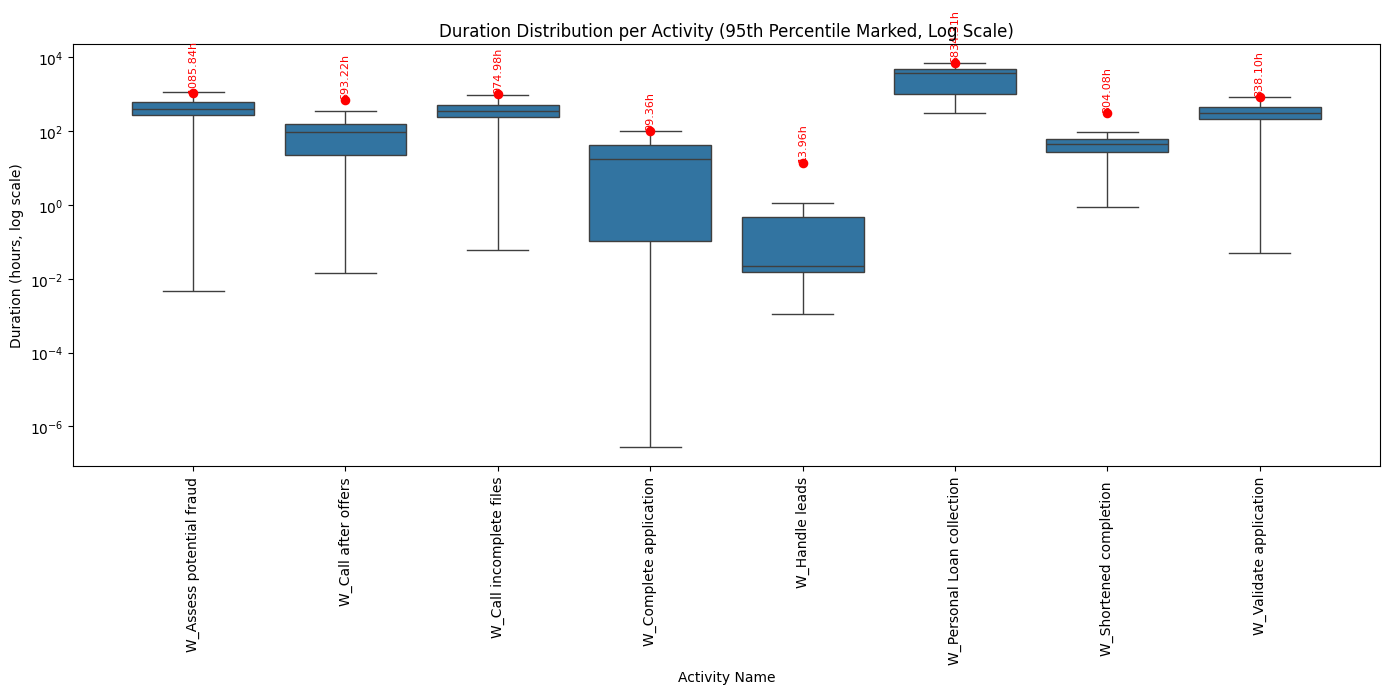

In [20]:
# duration distribution per activity with 95th percentile marker + label (log y-axis)
timeline_df = df.copy()
timeline_df["start_timestamp"] = timeline_df.groupby("case:concept:name")["time:timestamp"].transform("min")
timeline_df["duration_hours"] = (
    timeline_df["time:timestamp"] - timeline_df["start_timestamp"]
).dt.total_seconds() / 3600.0

# log-scale requires positive values
timeline_df = timeline_df[timeline_df["duration_hours"] > 0].copy()

activity_order = sorted(timeline_df["concept:name"].dropna().unique().tolist())
percentile_95 = timeline_df.groupby("concept:name")["duration_hours"].quantile(0.95)

plt.figure(figsize=(14, 7))
ax = sns.boxplot(
    x="concept:name",
    y="duration_hours",
    data=timeline_df,
    order=activity_order,
    showfliers=False
 )

# mark only the 95th percentile per activity and annotate in hours
for i, activity in enumerate(activity_order):
    p95 = percentile_95.get(activity, None)
    if p95 is None or pd.isna(p95) or p95 <= 0:
        continue
    ax.scatter(i, p95, color="red", s=35, zorder=5)
    ax.text(
        i,
        p95 * 1.08,
        f"{p95:.2f}h",
        ha="center",
        va="bottom",
        fontsize=8,
        color="red",
        rotation=90
    )

ax.set_yscale("log")
plt.xticks(rotation=90)
plt.title("Duration Distribution per Activity (95th Percentile Marked, Log Scale)")
plt.xlabel("Activity Name")
plt.ylabel("Duration (hours, log scale)")
plt.tight_layout()
plt.show()

In [21]:

# Basic stats
print("Total events (df):", len(df))
print("Unique cases:", df['case:concept:name'].nunique())
print("Time range:", df['time:timestamp'].min(), "->", df['time:timestamp'].max())

# Events per case distribution
events_per_case = df.groupby('case:concept:name').size()
print(events_per_case.describe())

# Top activities and resources
top_activities = df['concept:name'].value_counts().head(20)
print("Top activities:\n", top_activities)

if 'org:resource' in df.columns:
    print("Top resources:\n", df['org:resource'].value_counts().head(10))

# Number of unique variants (using pm4py utility)
variants = pm4py.get_variants(log)
print("Number of trace variants:", len(variants))

Total events (df): 768823
Unique cases: 31509
Time range: 2016-01-01 09:51:15.774000+00:00 -> 2017-02-01 14:11:03.499000+00:00
count    31509.000000
mean        24.400108
std         13.728895
min          3.000000
25%         14.000000
50%         21.000000
75%         31.000000
max        151.000000
dtype: float64
Top activities:
 concept:name
W_Validate application        209496
W_Call after offers           191092
W_Call incomplete files       168529
W_Complete application        148900
W_Handle leads                 47264
W_Assess potential fraud        3282
W_Shortened completion           238
W_Personal Loan collection        22
Name: count, dtype: int64
Top resources:
 org:resource
User_1      72626
User_87     18274
User_3      18139
User_30     16409
User_5      16232
User_100    15564
User_2      14971
User_123    14483
User_29     14011
User_49     13098
Name: count, dtype: int64
Number of trace variants: 15930


In [22]:
context_columns = ["case:LoanGoal", "case:RequestedAmount"]
# i want to analyze which resources work on which loan goals and requested amounts


In [23]:
index = 7
count = 0
res = ModuleNotFoundError
column = dict(df["concept:name"].value_counts())
for key,value in column.items():
    count += 1
    if index == count:
        res = key
    print(f"{key}: {value}")
print(res)

W_Validate application: 209496
W_Call after offers: 191092
W_Call incomplete files: 168529
W_Complete application: 148900
W_Handle leads: 47264
W_Assess potential fraud: 3282
W_Shortened completion : 238
W_Personal Loan collection: 22
W_Shortened completion 


In [24]:
df[df["concept:name"] == "W_Personal Loan collection"]["lifecycle:transition"].value_counts()

lifecycle:transition
suspend     9
resume      7
start       4
schedule    2
Name: count, dtype: int64

In [25]:
df[df["concept:name"] == "W_Shortened completion"]

,case:RequestedAmount,EventID,MonthlyCost,time:timestamp,EventOrigin,Selected,CreditScore,org:resource,NumberOfTerms,case:concept:name,concept:name,OfferedAmount,case:LoanGoal,Accepted,Action,lifecycle:transition,case:ApplicationType,OfferID,FirstWithdrawalAmount


In [26]:
df_lc = df[df['lifecycle:transition'].isin(['start', 'complete'])].copy()
df_lc['time:timestamp'] = pd.to_datetime(df_lc['time:timestamp'])

# Separate start and complete events
starts = df_lc[df_lc['lifecycle:transition'] == 'start'].sort_values(
    ['case:concept:name', 'concept:name', 'time:timestamp']
)
completes = df_lc[df_lc['lifecycle:transition'] == 'complete'].sort_values(
    ['case:concept:name', 'concept:name', 'time:timestamp']
)

# Add occurrence number for matching
starts['occurrence'] = starts.groupby(['case:concept:name', 'concept:name']).cumcount() + 1
completes['occurrence'] = completes.groupby(['case:concept:name', 'concept:name']).cumcount() + 1

# Prepare columns for merge
start_cols = ['case:concept:name', 'concept:name', 'occurrence', 'time:timestamp', 'org:resource', 'case:RequestedAmount', 'case:LoanGoal', 'case:ApplicationType']
complete_cols = ['case:concept:name', 'concept:name', 'occurrence', 'time:timestamp', 'org:resource', 'case:RequestedAmount', 'case:LoanGoal', 'case:ApplicationType']

# Merge start and complete events (OUTER join to keep all events)
merged = pd.merge(
    starts[start_cols],
    completes[complete_cols],
    on=['case:concept:name', 'concept:name', 'occurrence'],
    how='outer',  # Changed from inner to outer
    suffixes=('_start', '_complete')
)

# For events with only complete, use complete as both start and end (instant activity)
# Or estimate start time from complete - small duration
mask_complete_only = merged['time:timestamp_start'].isna()
merged.loc[mask_complete_only, 'time:timestamp_start'] = merged.loc[mask_complete_only, 'time:timestamp_complete']
merged.loc[mask_complete_only, 'org:resource_start'] = merged.loc[mask_complete_only, 'org:resource_complete']
# Copy context attributes for complete-only events
for attr in context_columns:
    attr_start = f"{attr}_start"
    attr_complete = f"{attr}_complete"
    if attr_start in merged.columns and attr_complete in merged.columns:
        merged[attr_start] = merged[attr_start].fillna(merged[attr_complete])

# Compute durations
merged['duration_seconds'] = (
    merged['time:timestamp_complete'] - merged['time:timestamp_start']
).dt.total_seconds()
merged['duration_hours'] = merged['duration_seconds'] / 3600.0

# For instant activities (complete-only), set small duration
merged.loc[mask_complete_only, 'duration_hours'] = (1.0 / 3600.0)  # 1 second

# Filter invalid durations (only negative ones)
initial_count = len(merged)
merged = merged[merged['duration_hours'] >= 0].copy()
filtered_count = initial_count - len(merged)

In [27]:
merged[merged["concept:name"] == "W_Shortened completion"]

,case:concept:name,concept:name,occurrence,time:timestamp_start,org:resource_start,case:RequestedAmount_start,case:LoanGoal_start,case:ApplicationType_start,time:timestamp_complete,org:resource_complete,case:RequestedAmount_complete,case:LoanGoal_complete,case:ApplicationType_complete,duration_seconds,duration_hours


/var/folders/82/ngnh3b854sb2dfv8lghfyr9r0000gn/T/ipykernel_71600/93150647.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['task_length'] = (df['time:timestamp'] - df.groupby('case:concept:name')['time:timestamp'].shift()).dt.total_seconds() / 60.0  # in minutes
/var/folders/82/ngnh3b854sb2dfv8lghfyr9r0000gn/T/ipykernel_71600/93150647.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['task_length'] = df['task_length'][df['task_length'] <= 10080]  # remove negative lengths if any
/var/folders/82/n

Task length statistics (minutes):
count    717616.000000
mean        641.427216
std        1721.848488
min           0.000017
25%           0.000150
50%           1.209333
75%          37.914379
max       10079.767783
Name: task_length, dtype: float64


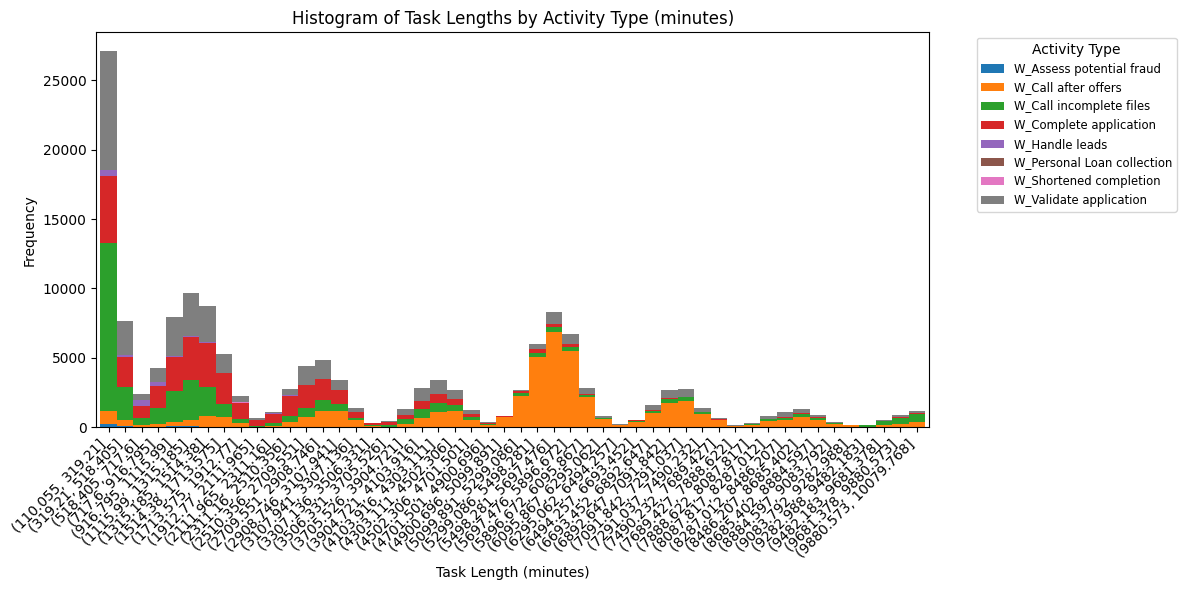

In [28]:
# i want to analyze the length of tasks. can you give me some statistics about the length of tasks in general by giving a histogram of task lengths??
df['task_length'] = (df['time:timestamp'] - df.groupby('case:concept:name')['time:timestamp'].shift()).dt.total_seconds() / 60.0  # in minutes
print("Task length statistics (minutes):")
df['task_length'] = df['task_length'][df['task_length'] <= 10080]  # remove negative lengths if any
print(df['task_length'].describe())
# only use the task lengths larger than 3 hours
df_filtered = df[df['task_length'] >= 120].dropna(subset=['task_length'])
# histogram of task lengths with stacked colors by activity type
# create bins for task lengths
task_length_bins = pd.cut(df_filtered['task_length'], bins=50)
# group by bins and activity type, then unstack
task_hist = df_filtered.groupby([task_length_bins, 'concept:name']).size().unstack(fill_value=0)
# plot as stacked bar chart
task_hist.plot(kind='bar', stacked=True, figsize=(12,6), width=1.0)
plt.title("Histogram of Task Lengths by Activity Type (minutes)")
plt.xlabel("Task Length (minutes)")
plt.ylabel("Frequency")
plt.legend(title='Activity Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


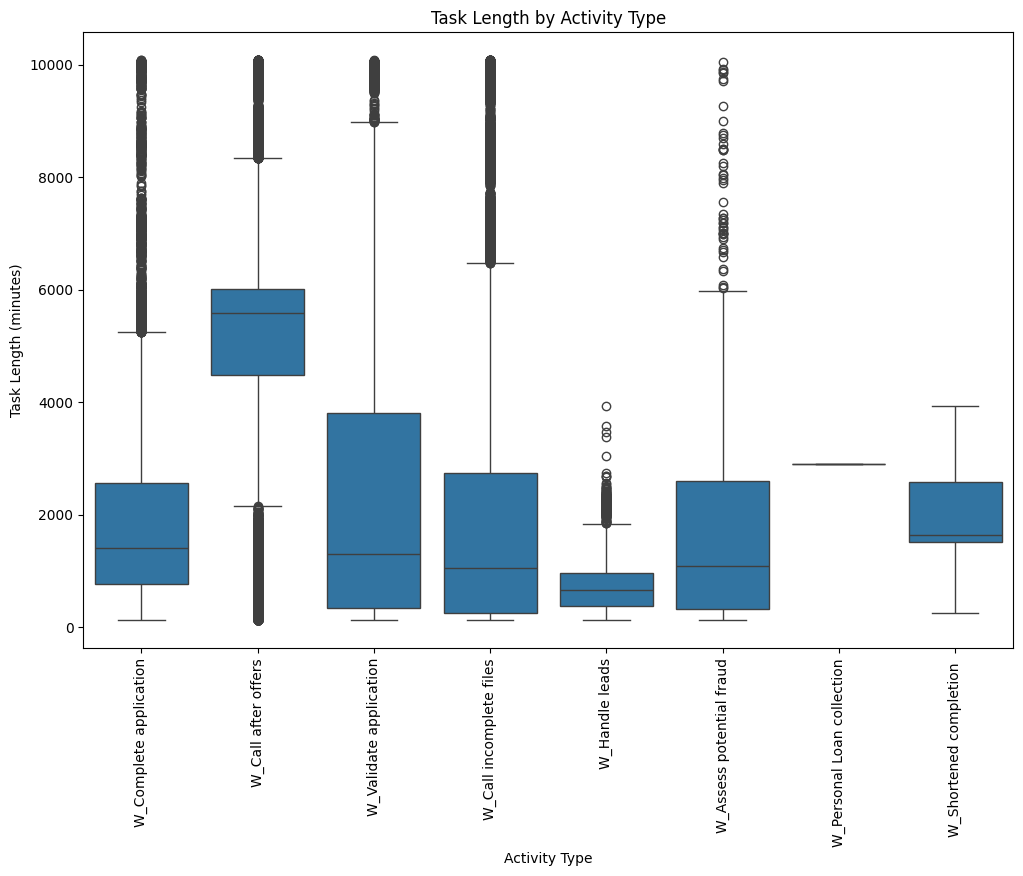

In [29]:
# visualize task length by activity type:
plt.figure(figsize=(12,8))
sns.boxplot(data=df_filtered, x='concept:name', y='task_length')
plt.xticks(rotation=90)
plt.title("Task Length by Activity Type")
plt.xlabel("Activity Type")
plt.ylabel("Task Length (minutes)")
plt.show()

### Analyze Cycle Time Distributions

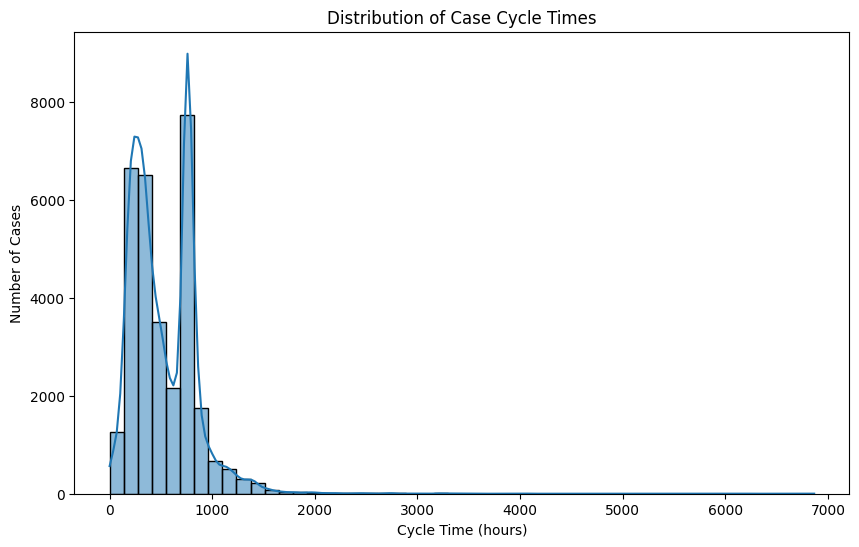

Cycle Time Statistics (hours):
count    31509.000000
mean       525.394470
std        316.140432
min          0.055848
25%        271.146061
50%        457.967079
75%        755.874209
max       6865.738508
Name: cycle_time_hours, dtype: float64


In [30]:
# analyze the cycle times per case:
# group all events by case and get the min and max timestamps, then visualize the distribution of cycle times as histogram
case_times = df.groupby('case:concept:name')['time:timestamp'].agg(['min', 'max'])
case_times['cycle_time_hours'] = (case_times['max'] - case_times['min']).dt.total_seconds() / 3600.0
# plot histogram of cycle times
plt.figure(figsize=(10,6))
sns.histplot(case_times['cycle_time_hours'], bins=50, kde=True)
plt.title("Distribution of Case Cycle Times")
plt.xlabel("Cycle Time (hours)")
plt.ylabel("Number of Cases")
plt.show()
# summarize cycle time statistics
print("Cycle Time Statistics (hours):")
print(case_times['cycle_time_hours'].describe())

In [31]:
df["case:RequestedAmount"].describe()

count    768823.000000
mean      16883.438235
std       15859.215360
min           0.000000
25%        6000.000000
50%       14000.000000
75%       23280.000000
max      450000.000000
Name: case:RequestedAmount, dtype: float64

In [32]:
print(f"<5000: {len(df[df[context_columns[1]] < 5000])}, relative: {(len(df[df[context_columns[1]] < 5000]) / len(df)):.4f}")
# print(f"<10000: {len(df[df[context_columns[1]] < 10000])}, relative: {(len(df[df[context_columns[1]] < 10000]) / len(df)):.4f}")
print(f"5000-9999: {len(df[(df[context_columns[1]] >= 5000) & (df[context_columns[1]] < 10000)])}, relative: {(len(df[(df[context_columns[1]] >= 5000) & (df[context_columns[1]] < 10000)]) / len(df)):.4f}")
print(f"10000-24999: {len(df[(df[context_columns[1]] >= 10000) & (df[context_columns[1]] < 25000)])}, relative: {(len(df[(df[context_columns[1]] >= 10000) & (df[context_columns[1]] < 25000)]) / len(df)):.4f}")
print(f"25000-99999: {len(df[(df[context_columns[1]] >= 25000) & (df[context_columns[1]] < 100000)])}, relative: {(len(df[(df[context_columns[1]] >= 25000) & (df[context_columns[1]] < 100000)]) / len(df)):.4f}")
print(f">=100000: {len(df[df[context_columns[1]] >= 100000])}, relative: {(len(df[df[context_columns[1]] >= 100000]) / len(df)):.4f}")

<5000: 71940, relative: 0.0936
5000-9999: 193017, relative: 0.2511
10000-24999: 317231, relative: 0.4126
25000-99999: 185950, relative: 0.2419
>=100000: 685, relative: 0.0009


/var/folders/82/ngnh3b854sb2dfv8lghfyr9r0000gn/T/ipykernel_71600/2106535183.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['RequestedAmountBin_vis'] = pd.cut(df[context_columns[1]], bins=bins, labels=labels, include_lowest=False)


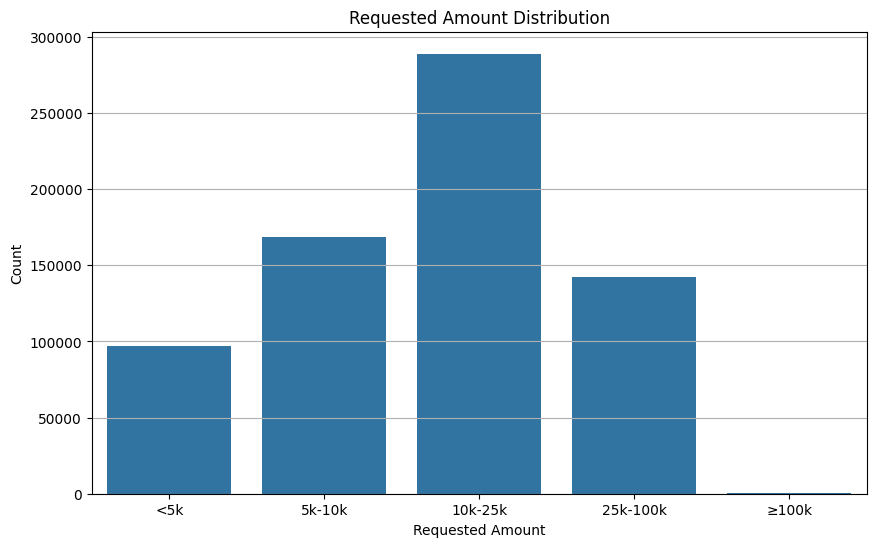

In [33]:
# visualize requested amount distribution by the bins from last cell
# Create categorical bins for equal-width bars
bins = [0, 5000, 10000, 25000, 100000, 450000]
labels = ['<5k', '5k-10k', '10k-25k', '25k-100k', '≥100k']
df['RequestedAmountBin_vis'] = pd.cut(df[context_columns[1]], bins=bins, labels=labels, include_lowest=False)

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='RequestedAmountBin_vis', order=labels)
plt.title("Requested Amount Distribution")
plt.xlabel("Requested Amount")
plt.ylabel("Count")
plt.grid(axis='y')
plt.show()

In [34]:
print(df[context_columns[1]].value_counts(bins=40).sort_index())

(-450.001, 11250.0]     346700
(11250.0, 22500.0]      225487
(22500.0, 33750.0]      106937
(33750.0, 45000.0]       46901
(45000.0, 56250.0]       24465
(56250.0, 67500.0]        7731
(67500.0, 78750.0]        9891
(78750.0, 90000.0]          26
(90000.0, 101250.0]        112
(101250.0, 112500.0]         0
(112500.0, 123750.0]        24
(123750.0, 135000.0]        25
(135000.0, 146250.0]         0
(146250.0, 157500.0]       161
(157500.0, 168750.0]        19
(168750.0, 180000.0]         0
(180000.0, 191250.0]         0
(191250.0, 202500.0]        76
(202500.0, 213750.0]         0
(213750.0, 225000.0]         0
(225000.0, 236250.0]         0
(236250.0, 247500.0]         0
(247500.0, 258750.0]        30
(258750.0, 270000.0]        28
(270000.0, 281250.0]        33
(281250.0, 292500.0]         0
(292500.0, 303750.0]        57
(303750.0, 315000.0]         0
(315000.0, 326250.0]         0
(326250.0, 337500.0]         0
(337500.0, 348750.0]        18
(348750.0, 360000.0]        30
(360000.

In [35]:
# analyze the min and max requested amounts per loangoal
for goal in df[context_columns[0]].unique():
    if "case:RequestedAmount" in df.columns:
        print(f"Loan goal: {goal}")
        print("Min requested amount:", df[df[context_columns[0]] == goal]["case:RequestedAmount"].min())
        print("Max requested amount:", df[df[context_columns[0]] == goal]["case:RequestedAmount"].max())
            

Loan goal: Existing loan takeover
Min requested amount: 0.0
Max requested amount: 400000.0
Loan goal: Home improvement
Min requested amount: 0.0
Max requested amount: 450000.0
Loan goal: Car
Min requested amount: 0.0
Max requested amount: 280000.0
Loan goal: Other, see explanation
Min requested amount: 0.0
Max requested amount: 400000.0
Loan goal: Remaining debt home
Min requested amount: 0.0
Max requested amount: 75000.0
Loan goal: Not speficied
Min requested amount: 0.0
Max requested amount: 75000.0
Loan goal: Unknown
Min requested amount: 0.0
Max requested amount: 300000.0
Loan goal: Caravan / Camper
Min requested amount: 0.0
Max requested amount: 75000.0
Loan goal: Tax payments
Min requested amount: 0.0
Max requested amount: 60000.0
Loan goal: Extra spending limit
Min requested amount: 0.0
Max requested amount: 75000.0
Loan goal: Motorcycle
Min requested amount: 0.0
Max requested amount: 60000.0
Loan goal: Boat
Min requested amount: 0.0
Max requested amount: 75000.0
Loan goal: Busi

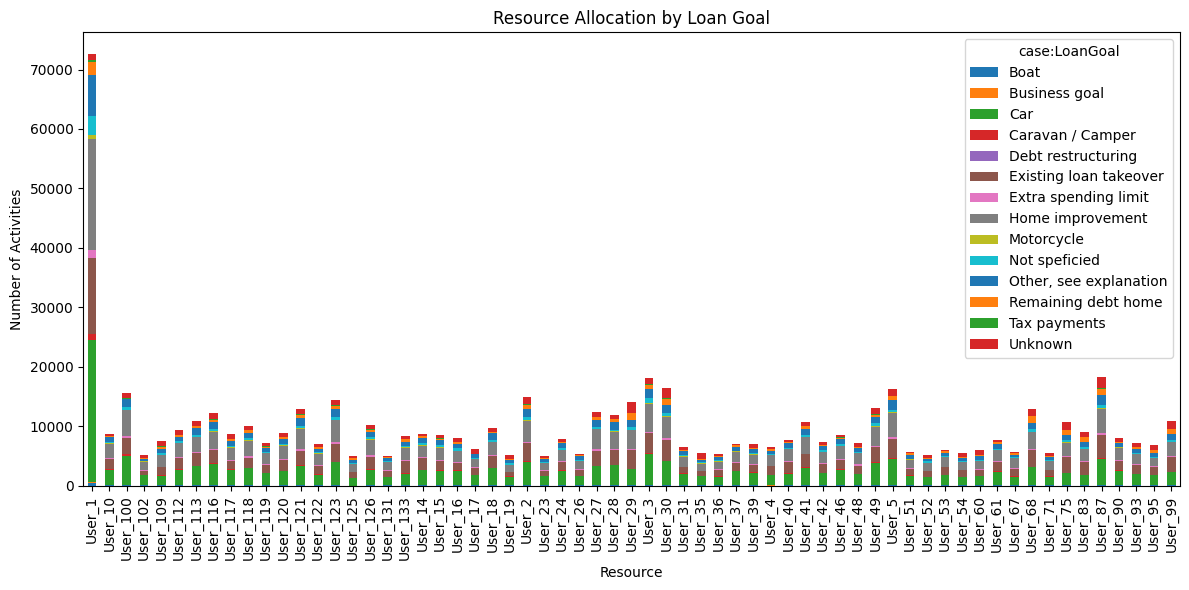

In [36]:
# Analyze resource allocation by LoanGoal
if 'org:resource' in df.columns and 'case:LoanGoal' in df.columns:
    resource_loangoal = df.groupby(['org:resource', 'case:LoanGoal']).size().unstack(fill_value=0)
    # only include resources that have worked on at least 50 activities
    resource_loangoal = resource_loangoal[resource_loangoal.sum(axis=1) >= 5000]
    # print("Resource allocation by LoanGoal:\n", resource_loangoal.head())
    resource_loangoal.plot(kind='bar', stacked=True, figsize=(12,6))
    plt.title("Resource Allocation by Loan Goal")
    plt.xlabel("Resource")
    plt.ylabel("Number of Activities")
    plt.tight_layout()
    plt.show()
    plt.close()

/var/folders/82/ngnh3b854sb2dfv8lghfyr9r0000gn/T/ipykernel_71600/3791075314.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['RequestedAmountBin'] = pd.cut(df['case:RequestedAmount'], bins=bins, labels=labels, include_lowest=True)
/var/folders/82/ngnh3b854sb2dfv8lghfyr9r0000gn/T/ipykernel_71600/3791075314.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resource_amountbin = df.groupby(['org:resource', 'RequestedAmountBin']).size().unstack(fill_value=0)


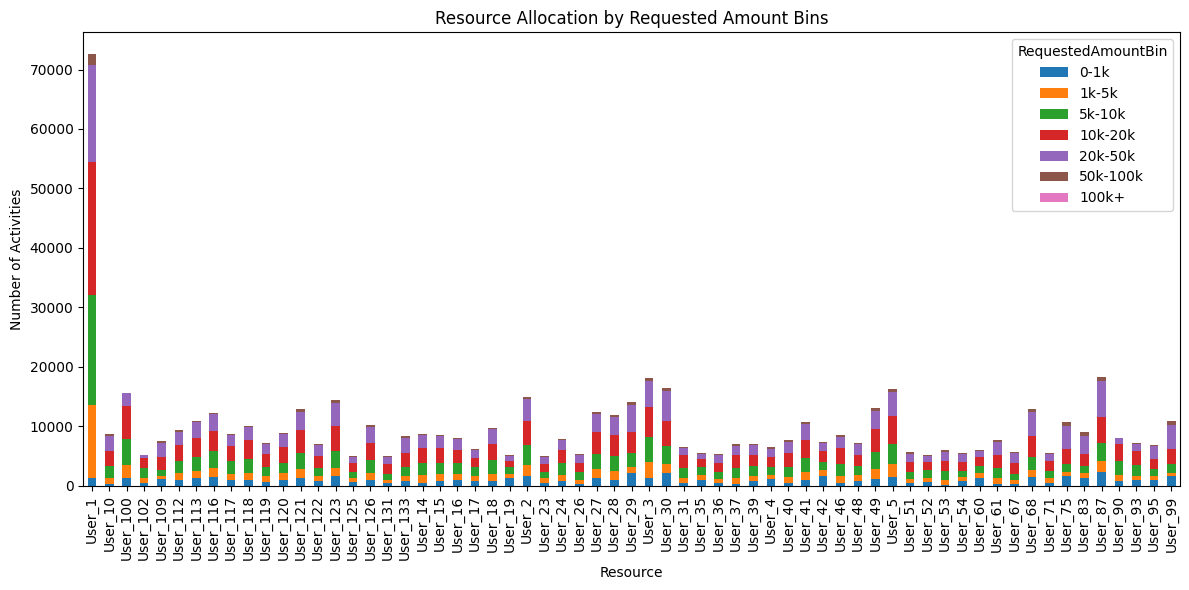

In [37]:
# Analyze resource allocation by RequestedAmount bins
if 'org:resource' in df.columns and 'case:RequestedAmount' in df.columns:
    # create bins for RequestedAmount
    bins = [0, 1000, 5000, 10000, 20000, 50000, 100000, df['case:RequestedAmount'].max()]
    labels = ['0-1k', '1k-5k', '5k-10k', '10k-20k', '20k-50k', '50k-100k', '100k+']
    df['RequestedAmountBin'] = pd.cut(df['case:RequestedAmount'], bins=bins, labels=labels, include_lowest=True)
    
    resource_amountbin = df.groupby(['org:resource', 'RequestedAmountBin']).size().unstack(fill_value=0)
    # only include resources that have worked on at least 50 activities
    resource_amountbin = resource_amountbin[resource_amountbin.sum(axis=1) >= 5000]
    # print("Resource allocation by RequestedAmount bins:\n", resource_amountbin.head())
    resource_amountbin.plot(kind='bar', stacked=True, figsize=(12,6))
    plt.title("Resource Allocation by Requested Amount Bins")
    plt.xlabel("Resource")
    plt.ylabel("Number of Activities")
    plt.tight_layout()
    plt.show()
    plt.close()

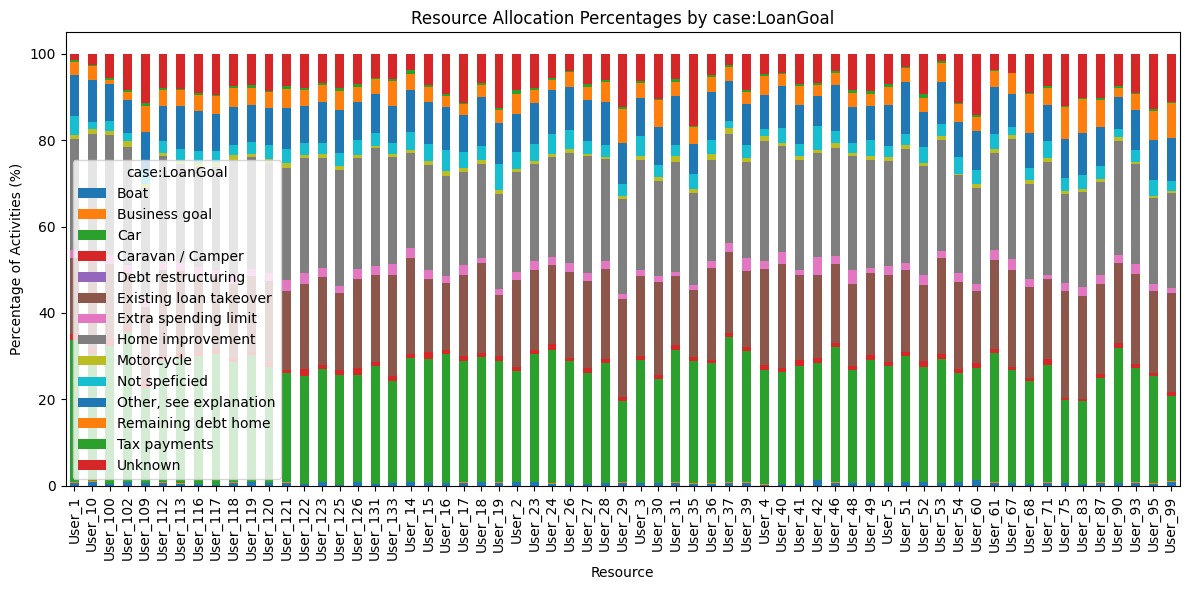

In [38]:
# visualize the percentage of all events that were dealt per resource for each context value
context_col = "case:LoanGoal"
if 'org:resource' in df.columns and context_col in df.columns:
    resource_context = df.groupby(['org:resource', context_col]).size().unstack(fill_value=0)
    resource_context = resource_context[resource_context.sum(axis=1) >= 5000]
    resource_context_pct = resource_context.div(resource_context.sum(axis=1), axis=0) * 100
    # print(f"Resource allocation percentages by {context_col}:\n", resource_context_pct.head())
    resource_context_pct.plot(kind='bar', stacked=True, figsize=(12,6))
    plt.title(f"Resource Allocation Percentages by {context_col}")
    plt.xlabel("Resource")
    plt.ylabel("Percentage of Activities (%)")
    plt.tight_layout()
    plt.show()
    plt.close()

/var/folders/82/ngnh3b854sb2dfv8lghfyr9r0000gn/T/ipykernel_71600/49584387.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resource_context = df.groupby(['org:resource', context_col]).size().unstack(fill_value=0)


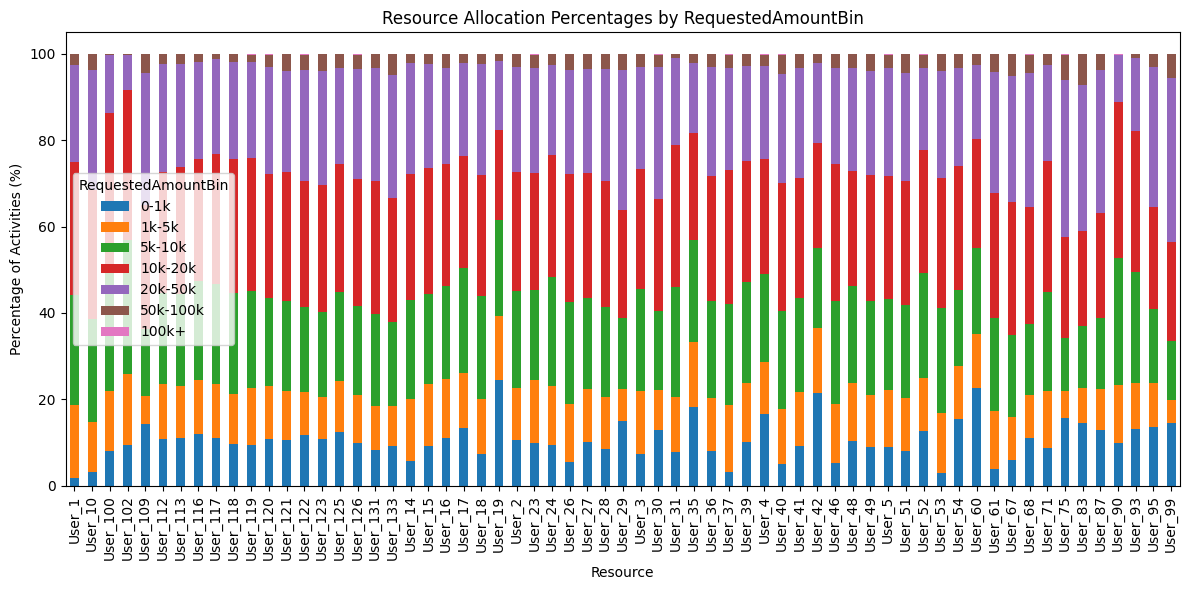

In [39]:
# the same as above but for RequestedAmountBin
context_col = "RequestedAmountBin"
if 'org:resource' in df.columns and context_col in df.columns:
    resource_context = df.groupby(['org:resource', context_col]).size().unstack(fill_value=0)
    resource_context = resource_context[resource_context.sum(axis=1) >= 5000]
    resource_context_pct = resource_context.div(resource_context.sum(axis=1), axis=0) * 100
    # print(f"Resource allocation percentages by {context_col}:\n", resource_context_pct.head())
    resource_context_pct.plot(kind='bar', stacked=True, figsize=(12,6))
    plt.title(f"Resource Allocation Percentages by {context_col}")
    plt.xlabel("Resource")
    plt.ylabel("Percentage of Activities (%)")
    plt.tight_layout()
    plt.show()
    plt.close()

/var/folders/82/ngnh3b854sb2dfv8lghfyr9r0000gn/T/ipykernel_71600/4248514797.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_resource = df.groupby(['RequestedAmountBin', 'org:resource']).size().unstack(fill_value=0)
/var/folders/82/ngnh3b854sb2dfv8lghfyr9r0000gn/T/ipykernel_71600/4248514797.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


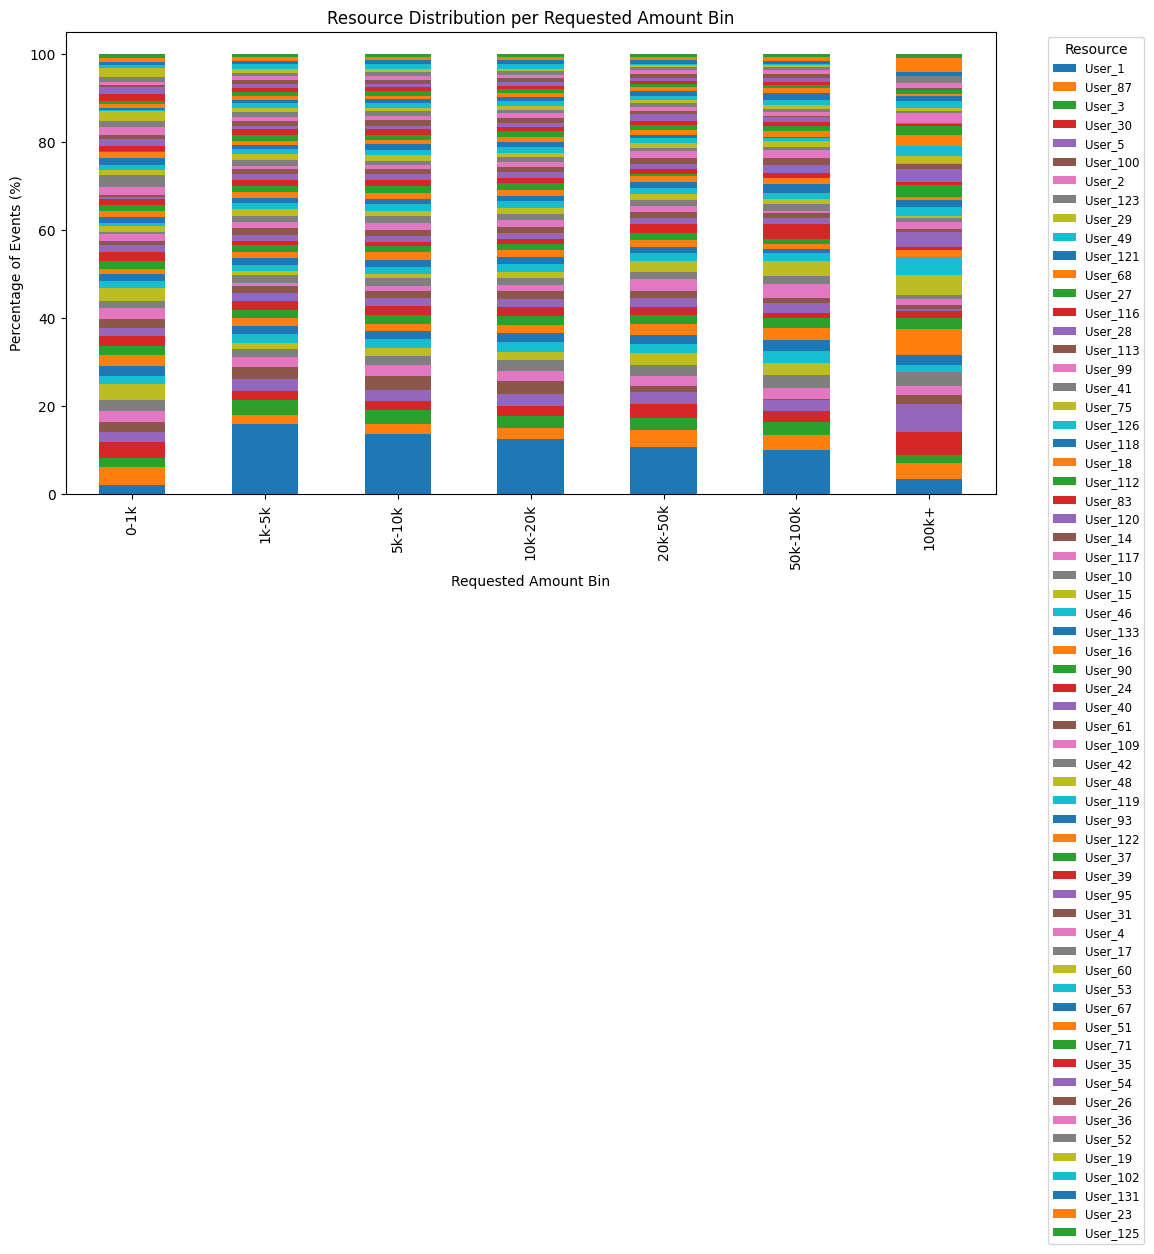

In [40]:
# visualize percentage of events per RequestedAmountBin, split by resource
if 'org:resource' in df.columns and 'RequestedAmountBin' in df.columns:
    # group by RequestedAmountBin and org:resource
    bin_resource = df.groupby(['RequestedAmountBin', 'org:resource']).size().unstack(fill_value=0)
    
    # only include resources that have worked on at least 5000 activities total
    resource_totals = bin_resource.sum(axis=0)
    active_resources = resource_totals[resource_totals >= 5000].index
    bin_resource = bin_resource[active_resources]
    
    # sort resources by total frequency (descending)
    resource_order = resource_totals[active_resources].sort_values(ascending=False).index
    bin_resource = bin_resource[resource_order]
    
    # calculate percentages per bin (each bin sums to 100%)
    bin_resource_pct = bin_resource.div(bin_resource.sum(axis=1), axis=0) * 100
    
    # plot
    bin_resource_pct.plot(kind='bar', stacked=True, figsize=(12,6))
    plt.title("Resource Distribution per Requested Amount Bin")
    plt.xlabel("Requested Amount Bin")
    plt.ylabel("Percentage of Events (%)")
    plt.legend(title='Resource', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    plt.tight_layout()
    plt.show()
    plt.close()

Generating process map...


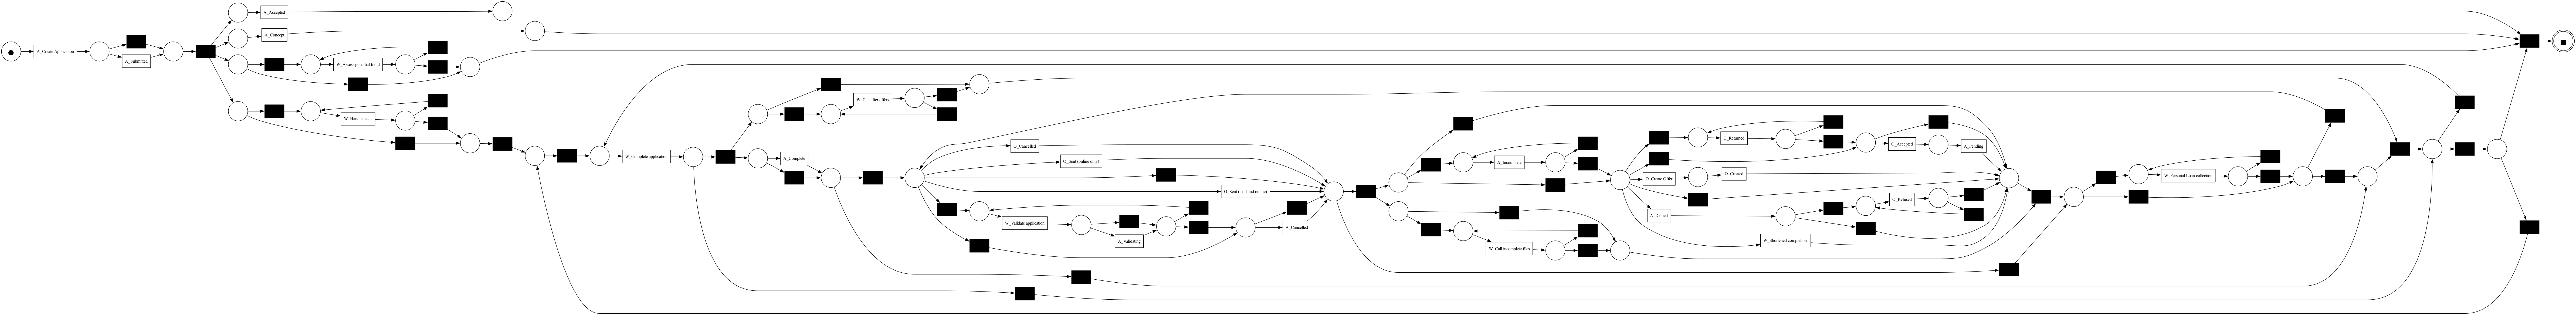

In [41]:
# visualize the process log using pm4py visualization
print("Generating process map...")
net, initial_marking, final_marking = pm4py.discover_petri_net_inductive(log)
# Visualize the Petri net
pm4py.view_petri_net(net, initial_marking, final_marking)


In [42]:
case_duration = pm4py.get_all_case_durations(df)
print(case_duration)

[201.054, 215.757, 281.689, 345.961, 370.825, 395.206, 411.924, 424.652, 449.333, 449.628, 455.433, 467.027, 472.766, 484.683, 485.157, 494.288, 501.492, 517.728, 545.374, 570.789, 600.913, 625.217, 628.504, 641.508, 646.084, 656.377, 670.549, 681.275, 714.201, 715.608, 731.306, 743.386, 804.503, 851.852, 890.609, 898.454, 906.352, 907.874, 915.711, 937.693, 950.908, 968.572, 984.634, 997.286, 1002.37, 1054.533, 1063.579, 1092.473, 1174.724, 1203.864, 1282.992, 1338.892, 1418.862, 1420.402, 1508.357, 1544.361, 1578.055, 1657.024, 1757.786, 1820.195, 1835.251, 1964.722, 2126.854, 2141.549, 2142.052, 2210.11, 2232.544, 2234.592, 2290.781, 2308.232, 2489.163, 2494.349, 2592.187, 2599.389, 2708.532, 2790.985, 2942.271, 3089.67, 3099.059, 3154.365, 3175.522, 3217.937, 3389.763, 3479.268, 3515.592, 3611.165, 3737.293, 3947.829, 3954.662, 4062.033, 4141.545, 4304.545, 4308.372, 4937.571, 5133.803, 5277.145, 5377.144, 5394.248, 5402.763, 5651.966, 5673.095, 5726.25, 5792.67, 5971.174, 6138.938

In [43]:
case_arrival = pm4py.get_case_arrival_average(df)
print(case_arrival)

1002.2343123016378


In [44]:
# i have the variant statistics in vbpi2017_eda_outputs/variant_statistics.csv saved in the format variant,count,percentage,length
variant_stats_path = OUT_DIR / "variant_statistics.csv"
variant_stats = pd.read_csv(variant_stats_path)
variant_stats = variant_stats[variant_stats["count"]>5]
variant_stats_less_than_10 = pd.read_csv(variant_stats_path)
variant_stats_less_than_10 = variant_stats_less_than_10[variant_stats_less_than_10["count"]<=5]
variant_stats.sort_values(by="count", ascending=False, inplace=True)

In [45]:
variant_stats_len = len(variant_stats)
print(variant_stats_len)

469


In [46]:
# create a variant alias column for easier visualization
variant_stats['variant_alias'] = [f"V{i+1}" for i in range(len(variant_stats))]

/var/folders/82/ngnh3b854sb2dfv8lghfyr9r0000gn/T/ipykernel_71600/4160004586.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=variant_stats, x="variant_alias", y="count", palette="viridis")


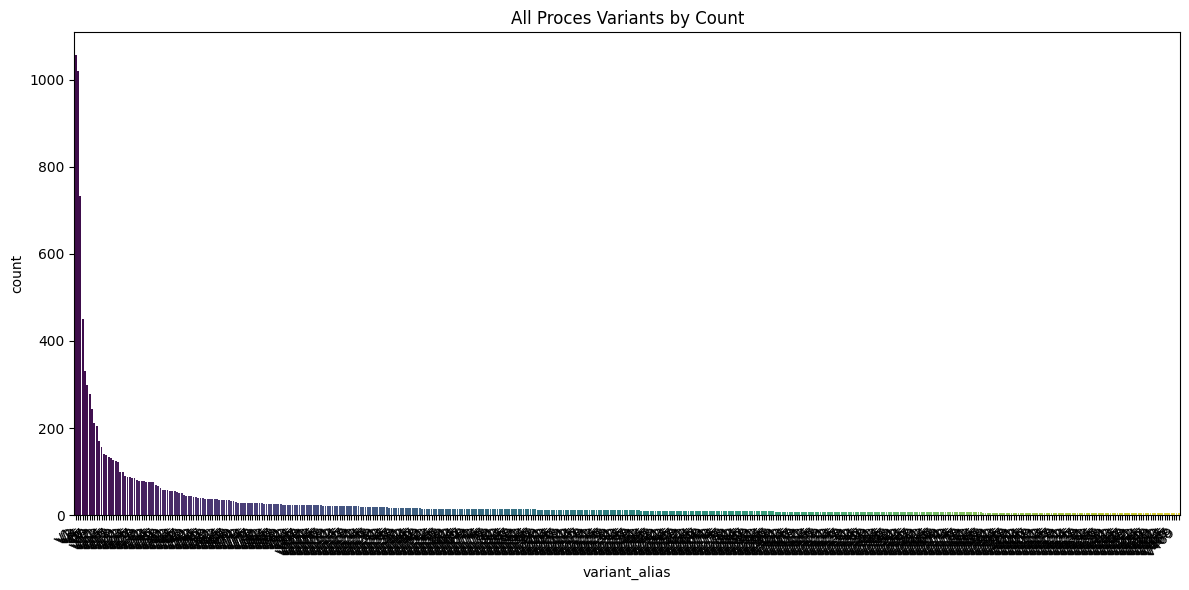

In [47]:
# visualize the variant distribution
plt.figure(figsize=(12,6))
sns.barplot(data=variant_stats, x="variant_alias", y="count", palette="viridis")
plt.xticks(rotation=45, ha='right')
plt.title("All Proces Variants by Count")
plt.tight_layout()
plt.show()

/var/folders/82/ngnh3b854sb2dfv8lghfyr9r0000gn/T/ipykernel_71600/567211923.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=variant_stats.head(30), x="variant_alias", y="count", palette="viridis")


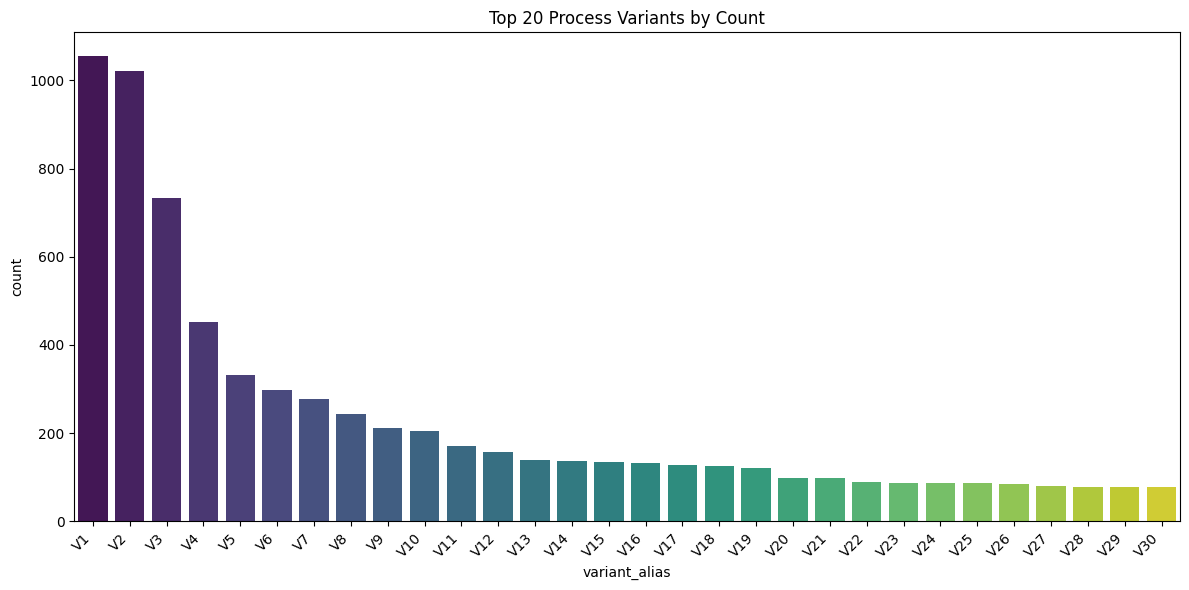

In [48]:
# visualize the variant distribution
plt.figure(figsize=(12,6))
sns.barplot(data=variant_stats.head(30), x="variant_alias", y="count", palette="viridis")
plt.xticks(rotation=45, ha='right')
plt.title("Top 20 Process Variants by Count")
plt.tight_layout()
plt.show()

/var/folders/82/ngnh3b854sb2dfv8lghfyr9r0000gn/T/ipykernel_71600/3418895316.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=variant_stats.iloc[200:250], x="variant_alias", y="count", palette="viridis")


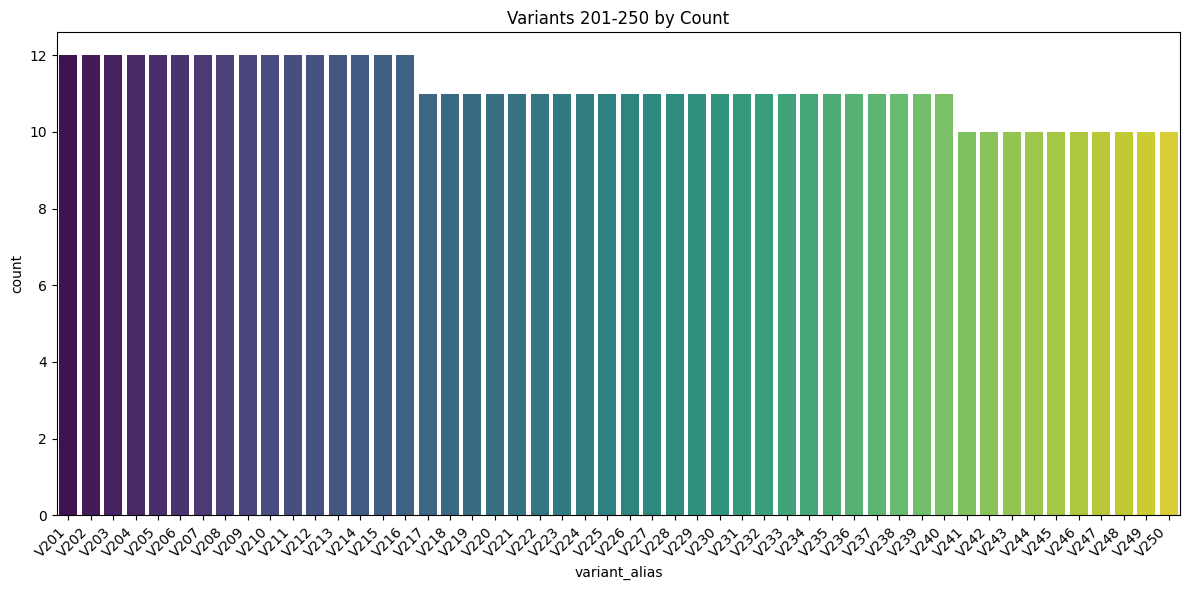

In [49]:
# now visualize the next 50 variants
plt.figure(figsize=(12,6))
sns.barplot(data=variant_stats.iloc[200:250], x="variant_alias", y="count", palette="viridis")
plt.xticks(rotation=45, ha='right')
plt.title("Variants 201-250 by Count")
plt.tight_layout()
plt.show()

In [50]:
# find out which percentage of all cases is within the variants with count > 10
variant_stats_path = OUT_DIR / "variant_statistics.csv"
variant_stats = pd.read_csv(variant_stats_path)
total_cases = variant_stats["count"].sum()
print(f"Total cases: {total_cases}")
# find out which percentage of all cases is within the variants with count < 10
print(variant_stats[variant_stats["count"]<=5]["count"].sum())
print(variant_stats[(variant_stats["count"]<=10) & (variant_stats["count"]>5)]["count"].sum())
print(variant_stats[(variant_stats["count"]<=15) & (variant_stats["count"]>10)]["count"].sum())
print(variant_stats[variant_stats["count"]>15]["count"].sum())
print("unique variants:", len(variant_stats))

print(f"Percentage of all cases in variants with count > 10: {(total_cases / n_traces) * 100:.2f}%")

Total cases: 31509
18029
1697
1189
10594
unique variants: 15930
Percentage of all cases in variants with count > 10: 2.62%


/var/folders/82/ngnh3b854sb2dfv8lghfyr9r0000gn/T/ipykernel_71600/3353172848.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=variant_stats.groupby("length")["count"].sum().reset_index(), x="length", y="count", palette="viridis")


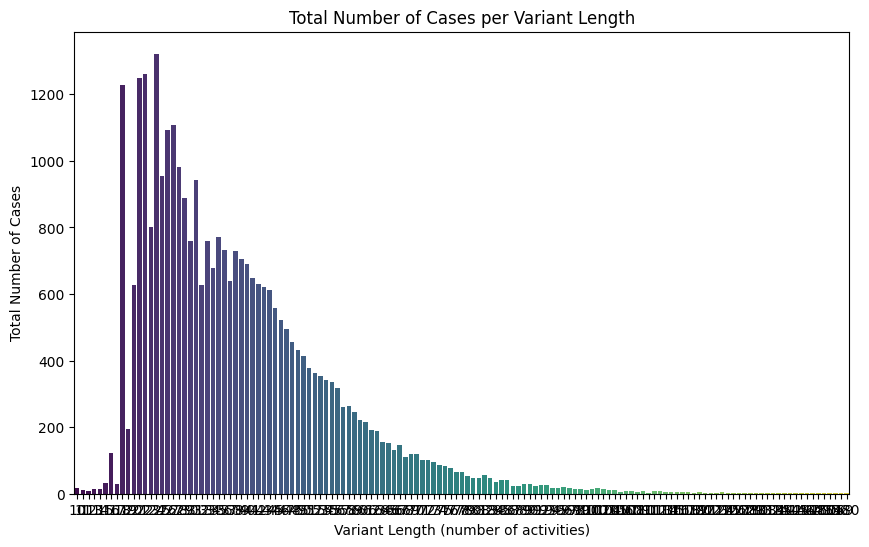

In [51]:
variant_stats_path = OUT_DIR / "variant_statistics.csv"
variant_stats = pd.read_csv(variant_stats_path)
plt.figure(figsize=(10,6))
sns.barplot(data=variant_stats.groupby("length")["count"].sum().reset_index(), x="length", y="count", palette="viridis")
plt.title("Total Number of Cases per Variant Length")
plt.xlabel("Variant Length (number of activities)")
plt.ylabel("Total Number of Cases")
plt.show()

/var/folders/82/ngnh3b854sb2dfv8lghfyr9r0000gn/T/ipykernel_71600/3763774773.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cumulative_counts = length_counts.groupby('length_bin')['count'].sum().cumsum().reset_index()


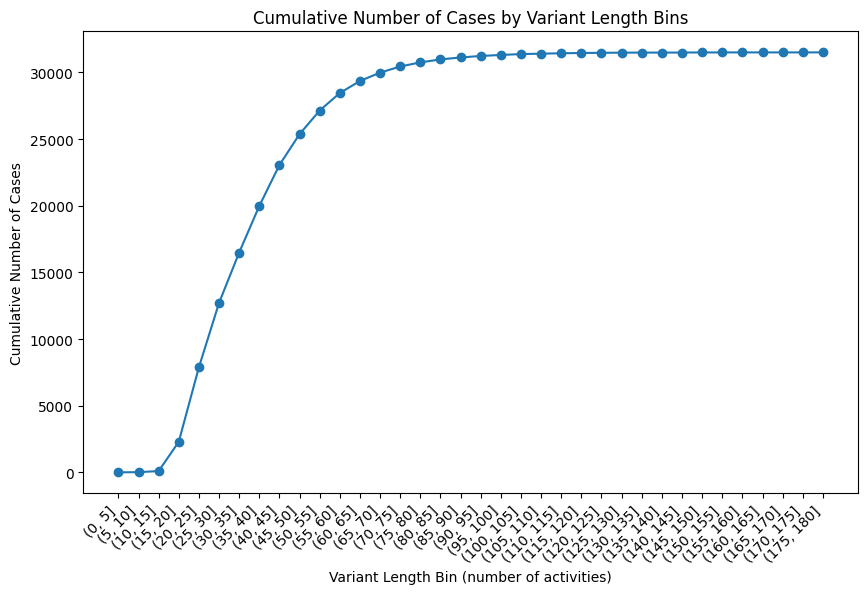

In [52]:
# cumulative graph of number of cases per variant length and put it into bins of size 5
plt.figure(figsize=(10,6))
length_counts = variant_stats.groupby("length")["count"].sum().reset_index()
length_counts['length_bin'] = pd.cut(length_counts['length'], bins=range(0, length_counts['length'].max() + 5, 5))
cumulative_counts = length_counts.groupby('length_bin')['count'].sum().cumsum().reset_index()
plt.plot(cumulative_counts['length_bin'].astype(str), cumulative_counts['count'], marker='o')
plt.xticks(rotation=45, ha='right')
plt.title("Cumulative Number of Cases by Variant Length Bins")
plt.xlabel("Variant Length Bin (number of activities)")
plt.ylabel("Cumulative Number of Cases")
plt.show()

## Simple Plots

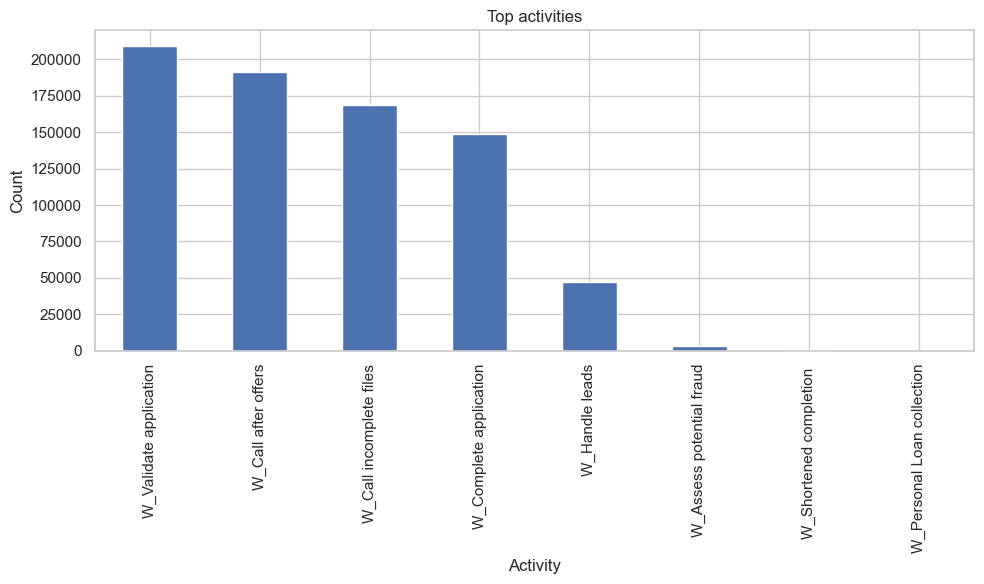

EDA outputs saved to: ../0_data/bpi2017_eda_outputs


In [53]:
sns.set(style="whitegrid")

plt.figure(figsize=(8,5))
sns.histplot(events_per_case, bins=50, kde=False)
plt.xlabel("Events per case")
plt.ylabel("Number of cases")
plt.title("Distribution of events per case")
plt.tight_layout()
plt.savefig(OUT_DIR / "events_per_case_hist.png")
plt.close()

plt.figure(figsize=(10,6))
top_activities.plot(kind="bar")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.title("Top activities")
plt.tight_layout()
plt.show()
plt.savefig(OUT_DIR / "top_activities.png")
plt.close()

# Save a sample of the DataFrame and aggregated stats
df.head(200).to_csv(OUT_DIR / "df_head_sample.csv", index=False)
events_per_case.to_csv(OUT_DIR / "events_per_case.csv", header=["count"])

print("EDA outputs saved to:", OUT_DIR)

In [54]:
df.columns

Index(['case:RequestedAmount', 'EventID', 'MonthlyCost', 'time:timestamp',
       'EventOrigin', 'Selected', 'CreditScore', 'org:resource',
       'NumberOfTerms', 'case:concept:name', 'concept:name', 'OfferedAmount',
       'case:LoanGoal', 'Accepted', 'Action', 'lifecycle:transition',
       'case:ApplicationType', 'OfferID', 'FirstWithdrawalAmount',
       'task_length', 'RequestedAmountBin_vis', 'RequestedAmountBin'],
      dtype='object')

In [55]:
# Warning: no start/complete pairs found by EventID. Check lifecycle transitions or EventID values.
df.head()


,case:RequestedAmount,EventID,MonthlyCost,time:timestamp,EventOrigin,Selected,CreditScore,org:resource,NumberOfTerms,case:concept:name,...,case:LoanGoal,Accepted,Action,lifecycle:transition,case:ApplicationType,OfferID,FirstWithdrawalAmount,task_length,RequestedAmountBin_vis,RequestedAmountBin
2,20000.0,Workitem_1298499574,NaN,2016-01-01 09:51:15.774000+00:00,Workflow,None,NaN,User_1,NaN,Application_652823628,...,Existing loan takeover,None,Created,schedule,New credit,None,NaN,NaN,10k-25k,10k-20k
3,20000.0,Workitem_1673366067,NaN,2016-01-01 09:52:36.392000+00:00,Workflow,None,NaN,User_1,NaN,Application_652823628,...,Existing loan takeover,None,Deleted,withdraw,New credit,None,NaN,1.343633,10k-25k,10k-20k
4,20000.0,Workitem_1493664571,NaN,2016-01-01 09:52:36.403000+00:00,Workflow,None,NaN,User_1,NaN,Application_652823628,...,Existing loan takeover,None,Created,schedule,New credit,None,NaN,0.000183,10k-25k,10k-20k
6,20000.0,Workitem_1875340971,NaN,2016-01-02 10:45:22.429000+00:00,Workflow,None,NaN,User_17,NaN,Application_652823628,...,Existing loan takeover,None,Obtained,start,New credit,None,NaN,1492.767100,10k-25k,10k-20k
7,20000.0,Workitem_1452291795,NaN,2016-01-02 10:49:28.816000+00:00,Workflow,None,NaN,User_17,NaN,Application_652823628,...,Existing loan takeover,None,Released,suspend,New credit,None,NaN,4.106450,10k-25k,10k-20k


In [56]:
df["org:resource"].value_counts()

org:resource
User_1      72626
User_87     18274
User_3      18139
User_30     16409
User_5      16232
            ...  
User_146       23
User_145       10
User_148        4
User_147        2
User_149        2
Name: count, Length: 149, dtype: int64

In [57]:
df[(df["org:resource"] == 'User_140') & ((df["lifecycle:transition"] == 'start') | (df["lifecycle:transition"] == 'complete'))]

,case:RequestedAmount,EventID,MonthlyCost,time:timestamp,EventOrigin,Selected,CreditScore,org:resource,NumberOfTerms,case:concept:name,...,case:LoanGoal,Accepted,Action,lifecycle:transition,case:ApplicationType,OfferID,FirstWithdrawalAmount,task_length,RequestedAmountBin_vis,RequestedAmountBin
772951,25000.0,Workitem_2082599029,NaN,2016-12-02 12:44:05.185000+00:00,Workflow,None,NaN,User_140,NaN,Application_2084907175,...,Existing loan takeover,None,Obtained,start,New credit,None,NaN,0.000083,10k-25k,20k-50k
980688,8000.0,Workitem_621869219,NaN,2016-12-02 11:59:50.703000+00:00,Workflow,None,NaN,User_140,NaN,Application_172695266,...,Existing loan takeover,None,Obtained,start,New credit,None,NaN,0.000050,5k-10k,5k-10k
1001071,15000.0,Workitem_880245925,NaN,2016-12-02 11:03:52.448000+00:00,Workflow,None,NaN,User_140,NaN,Application_1728000220,...,Existing loan takeover,None,Obtained,start,New credit,None,NaN,0.000033,10k-25k,10k-20k
1018487,0.0,Workitem_301730255,NaN,2016-12-02 12:34:56.865000+00:00,Workflow,None,NaN,User_140,NaN,Application_221473441,...,Unknown,None,Obtained,start,Limit raise,None,NaN,0.000033,NaN,0-1k
1025917,0.0,Workitem_645405123,NaN,2016-12-02 12:16:37.982000+00:00,Workflow,None,NaN,User_140,NaN,Application_1830261390,...,Unknown,None,Obtained,start,Limit raise,None,NaN,0.000033,NaN,0-1k
1033148,0.0,Workitem_638739283,NaN,2016-12-02 12:19:36.063000+00:00,Workflow,None,NaN,User_140,NaN,Application_2057354751,...,Unknown,None,Obtained,start,New credit,None,NaN,0.000050,NaN,0-1k
1033543,15000.0,Workitem_798042781,NaN,2016-12-02 12:37:49.478000+00:00,Workflow,None,NaN,User_140,NaN,Application_1474309108,...,Home improvement,None,Obtained,start,New credit,None,NaN,0.000033,10k-25k,10k-20k
1043001,5000.0,Workitem_1573595452,NaN,2016-12-02 12:22:51.051000+00:00,Workflow,None,NaN,User_140,NaN,Application_2060092602,...,Existing loan takeover,None,Obtained,start,New credit,None,NaN,0.000033,<5k,1k-5k
1044923,75000.0,Workitem_1004604110,NaN,2016-12-02 12:29:47.224000+00:00,Workflow,None,NaN,User_140,NaN,Application_649819908,...,Existing loan takeover,None,Obtained,start,New credit,None,NaN,0.000067,25k-100k,50k-100k
1046455,7500.0,Workitem_1954312877,NaN,2016-12-14 10:42:42.616000+00:00,Workflow,None,NaN,User_140,NaN,Application_217974632,...,Car,None,Obtained,start,New credit,None,NaN,0.000033,5k-10k,5k-10k


In [58]:
# check if there is a user for every number from 1 to 149 so if there exists "User_1", "User_2", ..., "User_149"
unique_users = df["org:resource"].unique()
user_numbers = set()
for user in unique_users:
    if user.startswith("User_"):
        try:
            num = int(user.split("_")[1])
            user_numbers.add(num)
        except ValueError:
            pass
missing_users = [i for i in range(1, 150) if i not in user_numbers]
print("Missing user numbers:", missing_users)
    

Missing user numbers: []


In [59]:
print(f"Number of unique resources: {df['org:resource'].nunique()}")

Number of unique resources: 149


In [60]:
print(f"Number of unique cases: {df['concept:name'].nunique()}")

Number of unique cases: 8


In [61]:
# now only count the users that are involved in an start or complete event:
# filter for lifecycle transitions
start_complete_df = df[df['lifecycle:transition'].isin(['start', 'complete'])]
unique_resources = start_complete_df['org:resource'].nunique()
unique_cases = start_complete_df['concept:name'].nunique()

In [62]:
print(f"Number of unique resources that performed start or complete events: {unique_resources}")
print(f"Number of unique cases with start or complete events: {unique_cases}")

Number of unique resources that performed start or complete events: 146
Number of unique cases with start or complete events: 8


Index(['case:concept:name', 'EventID', 'concept:name', 'start_time',
       'org:resource', 'case:LoanGoal', 'case:ApplicationType'],
      dtype='object')
Index(['case:concept:name', 'EventID', 'concept:name', 'complete_time',
       'org:resource', 'case:LoanGoal', 'case:ApplicationType'],
      dtype='object')


/var/folders/82/ngnh3b854sb2dfv8lghfyr9r0000gn/T/ipykernel_71600/2173164339.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['time:timestamp'] = pd.to_datetime(df['time:timestamp'])
/var/folders/82/ngnh3b854sb2dfv8lghfyr9r0000gn/T/ipykernel_71600/2173164339.py:48: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  merged['period_month'] = merged['complete_time'].dt.to_period('M').dt.to_timestamp()


Found 14286 non-positive durations — keep but mark as potential data issues.
Overall service-time statistics (hours):
 count    66438.000000
mean        21.320771
std        183.534831
min      -3316.656188
25%          0.008871
50%          0.266712
75%         44.311172
max       3813.741950
Name: service_duration_h, dtype: float64
merged cols: ['case:concept:name', 'EventID_start', 'concept:name', 'start_time', 'org:resource_start', 'case:LoanGoal_start', 'case:ApplicationType_start', 'EventID_complete', 'complete_time', 'org:resource_complete', 'case:LoanGoal_complete', 'case:ApplicationType_complete', 'service_duration_s', 'service_duration_h', 'period_month']
Monthly aggregated service-times saved.
Top activities for service-time trend plots: ['W_Validate application', 'W_Complete application', 'W_Call incomplete files', 'W_Handle leads', 'W_Call after offers', 'W_Assess potential fraud']


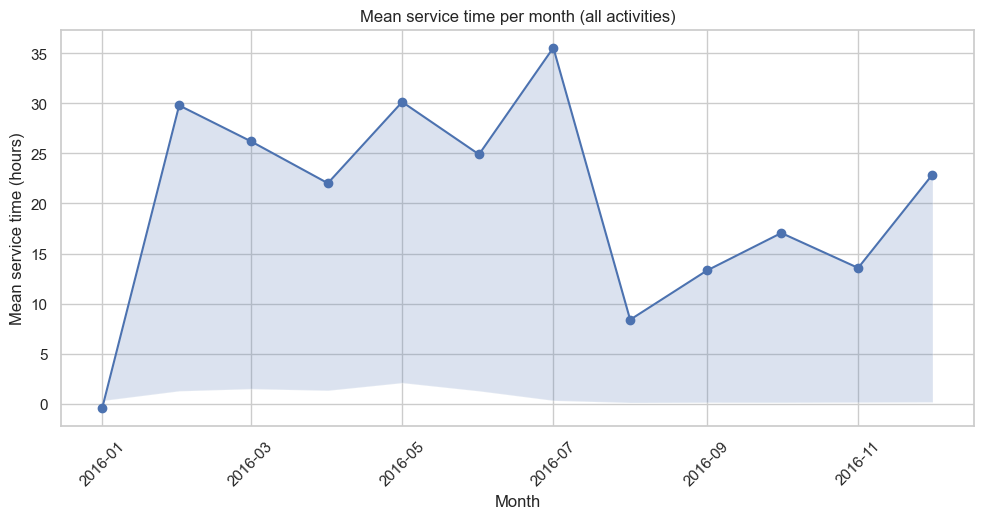

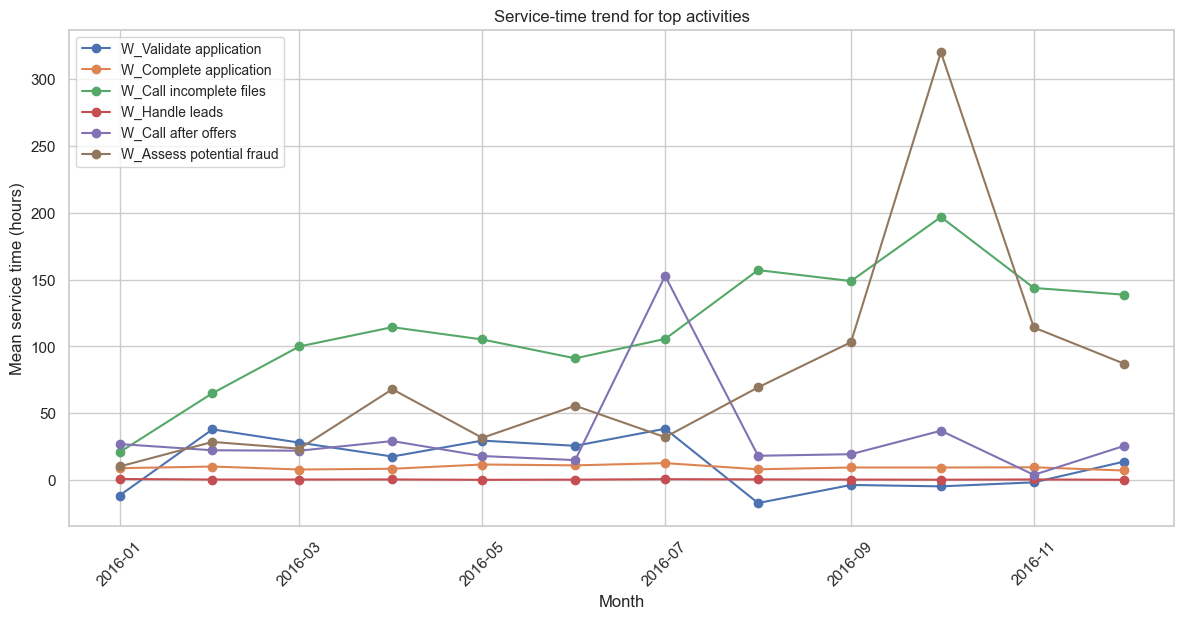

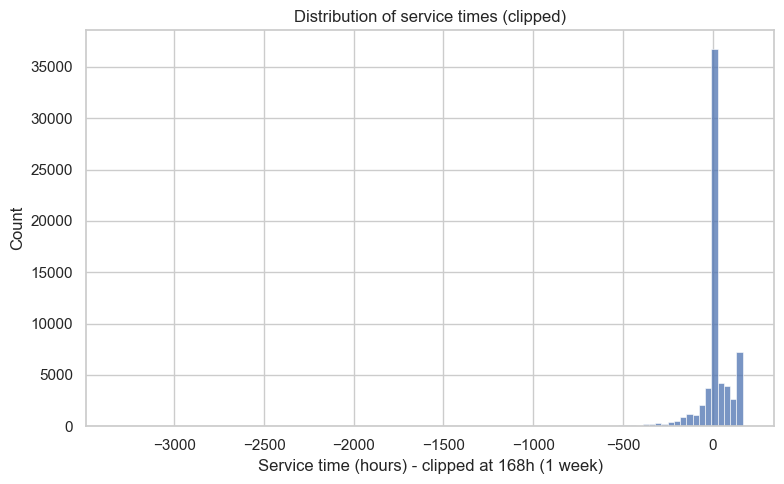

Service-time analysis complete. Outputs written to ../0_data/bpi2017_eda_outputs


In [63]:
# ---------- Service time analysis (add after previous cells) ----------
import numpy as np
from matplotlib.dates import DateFormatter

# ensure timestamps
df['time:timestamp'] = pd.to_datetime(df['time:timestamp'])
# timestamp has format dtype=datetime64[ns, UTC]
date = pd.Timestamp("2017-01-01", tz='UTC')
df = df[df['time:timestamp'] < date]

# keep only rows with lifecycle transitions of interest
if 'lifecycle:transition' in df.columns:
    df_lc = df[df['lifecycle:transition'].isin(['start', 'complete'])].copy()
else:
    raise ValueError("No 'lifecycle:transition' column found in df")

# prepare start and complete tables (using EventID as primary pairing key)
start = df_lc[df_lc['lifecycle:transition'] == 'start'][[
    'case:concept:name', 'EventID', 'concept:name', 'time:timestamp', 'org:resource', 'case:LoanGoal',  'case:ApplicationType'
]].rename(columns={'time:timestamp': 'start_time'})
print(start.columns)
complete = df_lc[df_lc['lifecycle:transition'] == 'complete'][[
    'case:concept:name', 'EventID', 'concept:name', 'time:timestamp', 'org:resource', 'case:LoanGoal', 'case:ApplicationType'
]].rename(columns={'time:timestamp': 'complete_time'})
print(complete.columns)
# Merge on case + EventID + activity name (EventID usually identifies the event instance)
merged = pd.merge(
    start,
    complete,
    on=['case:concept:name', 'concept:name'],
    how='inner',
    suffixes=('_start', '_complete')
)

# If merge is empty, warn user (may indicate lifecycle transitions or EventID missing)
if merged.empty:
    print("Warning: no start/complete pairs found by EventID. Check lifecycle transitions or EventID values.")
else:
    # compute duration
    merged['service_duration_s'] = (merged['complete_time'] - merged['start_time']).dt.total_seconds()
    # drop negative or zero durations (if any) and report
    neg_count = (merged['service_duration_s'] <= 0).sum()
    if neg_count:
        print(f"Found {neg_count} non-positive durations — keep but mark as potential data issues.")
    merged['service_duration_h'] = merged['service_duration_s'] / 3600.0

    # use complete_time as the timestamp for temporal aggregation (you can switch to start_time)
    merged['period_month'] = merged['complete_time'].dt.to_period('M').dt.to_timestamp()

    # Overall stats
    overall = merged['service_duration_h'].describe()
    print("Overall service-time statistics (hours):\n", overall)

    # quick inspect to confirm suffixes
    print("merged cols:", merged.columns.tolist())

    # canonicalize LoanGoal / ApplicationType coming from start/complete
    merged['case:LoanGoal'] = merged.get('case:LoanGoal_start').combine_first(merged.get('case:LoanGoal_complete'))
    merged['case:ApplicationType'] = merged.get('case:ApplicationType_start').combine_first(merged.get('case:ApplicationType_complete'))

    # Save full per-event service times
    merged_out = merged[[
        'case:concept:name', 'concept:name', 'org:resource_start', 'start_time', 'complete_time',
        'service_duration_s', 'service_duration_h', 'period_month', 'case:LoanGoal', 'case:ApplicationType'
    ]].rename(columns={'org:resource_start':'org:resource'})
    merged_out.to_csv(OUT_DIR / "service_times_per_event.csv", index=False)

    # Aggregate: monthly overall average/median
    monthly = merged_out.groupby('period_month').agg(
        count=('service_duration_h','count'),
        mean_h=('service_duration_h','mean'),
        median_h=('service_duration_h','median'),
        p95_h=('service_duration_h', lambda x: np.percentile(x,95))
    ).reset_index()
    monthly.to_csv(OUT_DIR / "service_times_monthly.csv", index=False)
    print("Monthly aggregated service-times saved.")

    # Aggregate: activity × month
    activity_month = merged_out.groupby(['concept:name','period_month']).agg(
        count=('service_duration_h','count'),
        mean_h=('service_duration_h','mean'),
        median_h=('service_duration_h','median')
    ).reset_index()
    activity_month.to_csv(OUT_DIR / "service_times_activity_month.csv", index=False)

    # Top activities by total occurrences
    top_activities = merged_out['concept:name'].value_counts().head(10).index.tolist()
    print("Top activities for service-time trend plots:", top_activities)

    # Plot overall monthly mean service time
    plt.figure(figsize=(10,5))
    plt.plot(monthly['period_month'], monthly['mean_h'], marker='o')
    plt.fill_between(monthly['period_month'], monthly['median_h'], monthly['mean_h'], alpha=0.2)
    plt.xlabel("Month")
    plt.ylabel("Mean service time (hours)")
    plt.title("Mean service time per month (all activities)")
    plt.grid(True)
    plt.tight_layout()
    plt.gca().xaxis.set_major_formatter(DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)
    plt.show()
    plt.savefig(OUT_DIR / "service_time_monthly_mean.png")
    plt.close()

    # Plot trends for top activities
    plt.figure(figsize=(12,6))
    for act in top_activities:
        sub = activity_month[activity_month['concept:name']==act]
        if sub.empty:
            continue
        plt.plot(sub['period_month'], sub['mean_h'], marker='o', label=act)
    plt.xlabel("Month")
    plt.ylabel("Mean service time (hours)")
    plt.title("Service-time trend for top activities")
    plt.legend(loc='best', fontsize='small')
    plt.grid(True)
    plt.tight_layout()
    plt.gca().xaxis.set_major_formatter(DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)
    plt.show()
    plt.savefig(OUT_DIR / "service_time_top_activities_trend.png")
    plt.close()

    # Distribution plot (all service times)
    plt.figure(figsize=(8,5))
    sns.histplot(merged_out['service_duration_h'].clip(upper=168), bins=100)  # clip to 1 week for visibility
    plt.xlabel("Service time (hours) - clipped at 168h (1 week)")
    plt.ylabel("Count")
    plt.title("Distribution of service times (clipped)")
    plt.tight_layout()
    plt.show()
    plt.savefig(OUT_DIR / "service_time_distribution_clipped.png")
    plt.close()

    # Save a short summary
    summary = {
        "total_service_events": int(len(merged_out)),
        "monthly_periods": int(monthly.shape[0]),
        "activities_measured": int(merged_out['concept:name'].nunique())
    }
    pd.Series(summary).to_csv(OUT_DIR / "service_time_summary.csv")

    print("Service-time analysis complete. Outputs written to", OUT_DIR)

# ---------- optional: waiting times between consecutive activities per case ----------
# If you also want waiting times (time between end of one event and start of next within same case),
# uncomment and run the following block:

# df_sorted = df.sort_values(['case:concept:name', 'time:timestamp'])
# df_sorted['next_time'] = df_sorted.groupby('case:concept:name')['time:timestamp'].shift(-1)
# df_sorted['wait_s'] = (df_sorted['next_time'] - df_sorted['time:timestamp']).dt.total_seconds()
# waits = df_sorted.dropna(subset=['wait_s'])
# waits['period_month'] = waits['time:timestamp'].dt.to_period('M').dt.to_timestamp()
# waits.groupby('period_month')['wait_s'].agg(['count','mean','median']).to_csv(OUT_DIR / "waiting_times_monthly.csv")

# ...existing code...

Top worker: User_116 count: 3177


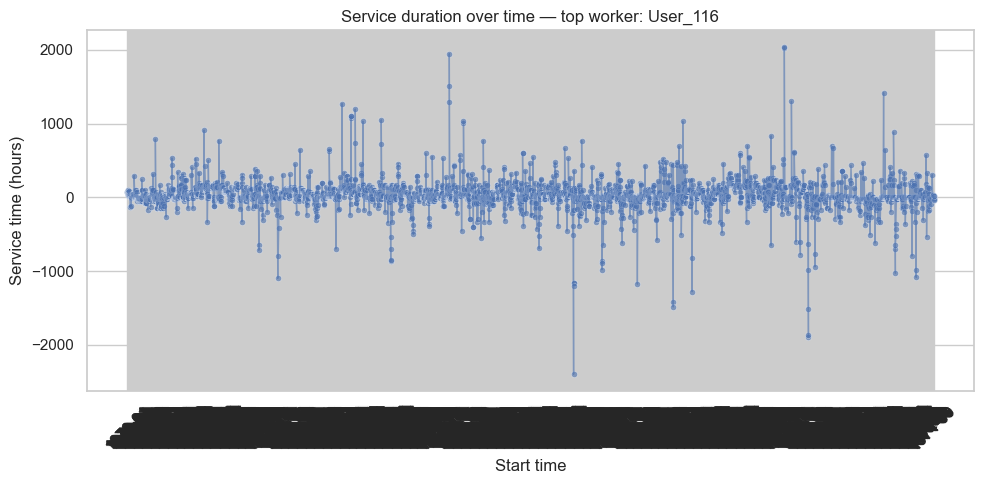

Saved plot to: ../0_data/bpi2017_eda_outputs/service_time_top_worker_User_116.png


In [64]:
# New cell: plot top worker service times over start_time

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import DateFormatter

OUT_DIR = Path("../0_data/bpi2017_eda_outputs")  # keep same OUT_DIR as notebook

# read the CSV produced earlier
csv_path = OUT_DIR / "service_times_per_event.csv"
df_events = pd.read_csv(csv_path, parse_dates=['start_time','complete_time'])

# find worker with most events
top_worker = df_events['org:resource'].value_counts().idxmax()
print("Top worker:", top_worker, "count:", int(df_events['org:resource'].value_counts().max()))

# filter and sort by start_time
worker_df = df_events[df_events['org:resource'] == top_worker].sort_values('start_time')

# plot
sns.set(style="whitegrid")
plt.figure(figsize=(10,5))
sns.scatterplot(data=worker_df, x='start_time', y='service_duration_h', s=20, alpha=0.6)
sns.lineplot(data=worker_df, x='start_time', y='service_duration_h', estimator=None, lw=1, alpha=0.6)
plt.xlabel("Start time")
plt.ylabel("Service time (hours)")
plt.title(f"Service duration over time — top worker: {top_worker}")
plt.gca().xaxis.set_major_formatter(DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()

# save and show
out_png = OUT_DIR / f"service_time_top_worker_{str(top_worker).replace(' ','_')}.png"
plt.savefig(out_png)
plt.show()

print("Saved plot to:", out_png)

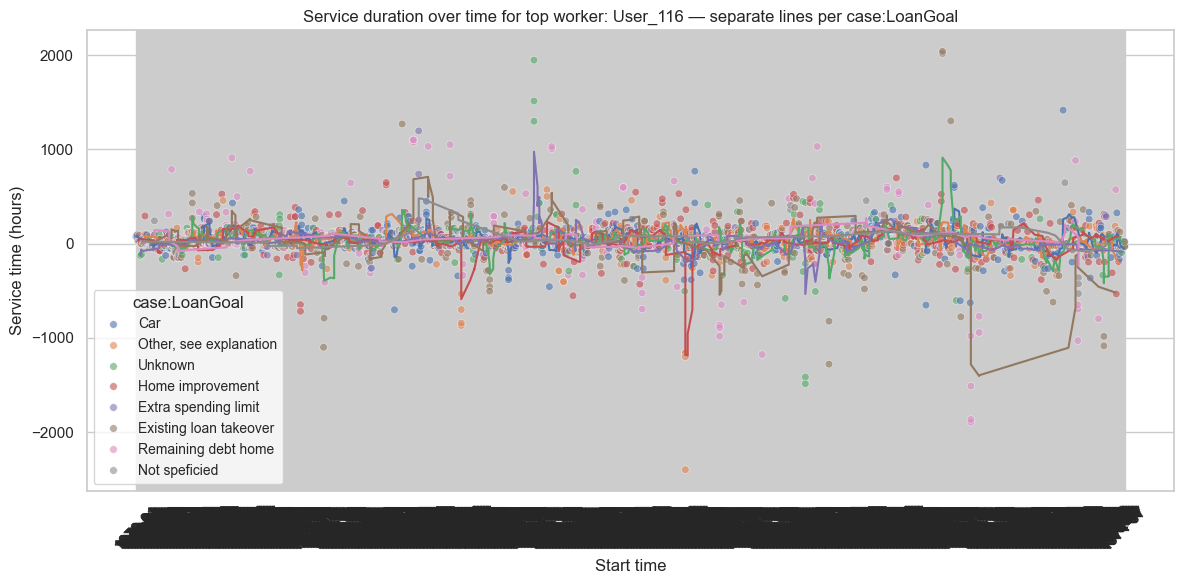

Saved plot to: ../0_data/bpi2017_eda_outputs/service_time_top_worker_by_LoanGoal_User_116.png


In [65]:
# ...existing code...

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import DateFormatter
from pathlib import Path

OUT_DIR = Path("../0_data/bpi2017_eda_outputs")
csv_path = OUT_DIR / "service_times_per_event.csv"
df = pd.read_csv(csv_path, parse_dates=['start_time','complete_time'])

# ensure service_duration_h exists
if 'service_duration_h' not in df.columns:
    df['service_duration_h'] = pd.to_numeric(df.get('service_duration_s', 0), errors='coerce') / 3600.0

# ensure LoanGoal column (handle suffixes)
loan_col = None
for c in ['case:LoanGoal','case:LoanGoal_start','case:LoanGoal_complete']:
    if c in df.columns:
        loan_col = c
        break
if loan_col is None:
    df['case:LoanGoal'] = 'UNKNOWN'
else:
    df['case:LoanGoal'] = df[loan_col].fillna('UNKNOWN')

# pick top worker
top_worker = df['org:resource'].value_counts().idxmax()
worker_df = df[df['org:resource'] == top_worker].sort_values('start_time')

# if many LoanGoal values, restrict to top N for clarity
TOP_N_GOALS = 8
top_goals = worker_df['case:LoanGoal'].value_counts().head(TOP_N_GOALS).index.tolist()
plot_df = worker_df[worker_df['case:LoanGoal'].isin(top_goals)].copy()

sns.set(style="whitegrid")
plt.figure(figsize=(12,6))

# scatter points colored by LoanGoal
sns.scatterplot(data=plot_df, x='start_time', y='service_duration_h', hue='case:LoanGoal', alpha=0.6, s=30)

# add a simple rolling-average trend per LoanGoal
for goal in top_goals:
    sub = plot_df[plot_df['case:LoanGoal'] == goal].sort_values('start_time')
    if len(sub) < 2:
        continue
    rolling = sub['service_duration_h'].rolling(window=5, min_periods=1).mean()
    plt.plot(sub['start_time'].values, rolling.values, linestyle='-', linewidth=1.5)

plt.xlabel("Start time")
plt.ylabel("Service time (hours)")
plt.title(f"Service duration over time for top worker: {top_worker} — separate lines per case:LoanGoal")
plt.gca().xaxis.set_major_formatter(DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.legend(title='case:LoanGoal', loc='best', fontsize='small')
plt.tight_layout()

out_png = OUT_DIR / f"service_time_top_worker_by_LoanGoal_{str(top_worker).replace(' ','_')}.png"
plt.savefig(out_png)
plt.show()

print("Saved plot to:", out_png)

# ...existing code...